# Diabetes Classification using Machine Learning Life Cycle

Dataset yang digunakan adalah Pima Indians Diabetes Dataset. Target prediksi pada dataset ini adalah kolom `Outcome`, yaitu apakah seseorang terindikasi diabetes atau tidak.

## 1. Business Understanding

**Target prediksi:**

- `Outcome = 0` berarti pasien tidak terindikasi diabetes.
- `Outcome = 1` berarti pasien terindikasi diabetes.

Jenis masalah:

- Supervised Learning
- Binary Classification

## 2. Import library & Dataset

In [3]:
import pandas as pd
import numpy as np

# Library visualisasi akan digunakan nanti pada tahap EDA
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

## 3. Load Dataset

Pada tahap ini dataset akan dimuat ke dalam notebook.

kalo pake Google Colab, upload file `pima-indians-diabetes.csv` dulu

In [4]:
# Membaca dataset

df = pd.read_csv('/content/pima-indians-diabetes.csv')

# Menampilkan ukuran dataset
print("Ukuran dataset:", df.shape)

# Menampilkan 5 data pertama
df.head()

Ukuran dataset: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 4. Initial Data Understanding

Pada tahap ini kita akan melihat struktur awal dataset, termasuk nama kolom, jumlah data, tipe data, dan contoh isi data.

Tujuannya adalah untuk memahami bentuk data sebelum melakukan cleaning, preprocessing, atau modeling.

In [9]:
# Melihat informasi ringkasan dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetespedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [10]:
# Melihat 5 data pertama

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [11]:
# melihat 5 data terakhir

df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


### Keterangan Awal Fitur

Berdasarkan nama kolom, dataset memiliki beberapa fitur, yaitu:

| Kolom | Keterangan Awal |
|---|---|
| Pregnancies | Jumlah kehamilan |
| Glucose | Kadar glukosa |
| BloodPressure | Tekanan darah |
| SkinThickness | Ketebalan lipatan kulit |
| Insulin | Kadar insulin |
| BMI | Body Mass Index |
| DiabetespedigreeFunction | Riwayat/indikasi faktor keturunan diabetes |
| Age | Usia pasien |
| Outcome | Target klasifikasi diabetes |

Kolom `Outcome` adalah target yang akan diprediksi.

## 5. Initial Data Quality Checking

Setelah memahami struktur awal dataset, tahap berikutnya adalah mengecek kualitas data.

Hal-hal yang perlu dicek:

1. Missing value
2. Duplikasi data
3. Distribusi target
4. Statistik deskriptif
5. Nilai tidak wajar, terutama nilai 0 pada fitur medis tertentu

In [12]:
# Mengecek missing value

missing_values = df.isnull().sum()

missing_values

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetespedigreeFunction,0
Age,0
Outcome,0


In [13]:
# Mengecek jumlah data duplikat

duplicate_count = df.duplicated().sum()

print("Jumlah data duplikat:", duplicate_count)

Jumlah data duplikat: 0


In [14]:
# Mengecek distribusi target

target_count = df['Outcome'].value_counts()
target_percentage = df['Outcome'].value_counts(normalize=True) * 100

target_distribution = pd.DataFrame({
    'Jumlah Data': target_count,
    'Persentase (%)': target_percentage.round(2)
})

target_distribution

,Jumlah Data,Persentase (%)
Outcome,,
0,500,65.1
1,268,34.9


In [19]:
# Statistik deskriptif fitur numerik

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetespedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [20]:
# Mengecek jumlah nilai 0 pada kolom medis tertentu

zero_check_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

zero_counts = (df[zero_check_columns] == 0).sum()
zero_percentage = ((df[zero_check_columns] == 0).sum() / len(df)) * 100

zero_summary = pd.DataFrame({
    'Jumlah Nilai 0': zero_counts,
    'Persentase (%)': zero_percentage.round(2)
})

zero_summary

,Jumlah Nilai 0,Persentase (%)
Glucose,5,0.65
BloodPressure,35,4.56
SkinThickness,227,29.56
Insulin,374,48.70
BMI,11,1.43


### Catatan Sementara hasil Initial Data Understanding

Berdasarkan pemeriksaan awal:

1. Dataset memiliki 768 baris dan 9 kolom.
2. Semua fitur berbentuk numerik.
3. Target klasifikasi adalah `Outcome`.
4. Kolom `Outcome` merupakan target biner:

   * `Outcome = 0` berarti tidak diabetes.
   * `Outcome = 1` berarti diabetes.
5. Tidak ditemukan missing value dalam bentuk NaN.
6. Tidak ditemukan data duplikat.
7. Distribusi target agak tidak seimbang, dimana outcome 0 lebih banyak dibanding Outcome 1.
8. Tidak semua nilai 0 dianggap bermasalah.

   * Nilai 0 pada `Outcome` valid karena merupakan label kelas.
   * Nilai 0 pada `Pregnancies` valid karena seseorang bisa saja belum pernah mengalami kehamilan.
9. Beberapa fitur numerik medis memiliki nilai 0 yang kemungkinan tidak realistis atau dapat dianggap sebagai missing value tersembunyi:

   * `Glucose`
   * `BloodPressure`
   * `SkinThickness`
   * `Insulin`
   * `BMI`

Kesimpulan sementara:

Dataset cukup sederhana secara struktur karena seluruh fitur berbentuk numerik dan tidak terdapat missing value dalam bentuk NaN. Namun, dataset ini tetep punya masalah kualitas data yang perlu menjadi perhatian, terutama adanya nilai 0 pada beberapa fitur numerik medis yang secara konteks kemungkinan tidak realistis.


## 6. Exploratory Data Analysis




Exploratory Data Analysis atau EDA dilakukan untuk memahami pola, distribusi, dan hubungan antar fitur pada dataset.

Pada tahap ini, analisis difokuskan pada:

1. Distribusi target `Outcome`.
2. Distribusi setiap fitur numerik.
3. Deteksi awal outlier.
4. Hubungan antar fitur menggunakan korelasi.
5. Perbandingan fitur berdasarkan kelas target.
6. Analisis nilai 0 pada fitur numerik medis berdasarkan target.

Tahap ini belum melakukan preprocessing atau perbaikan data. Tujuannya adalah memahami karakteristik dataset sebelum menentukan strategi preprocessing yang tepat.

### 6.1 Distribusi Target

Langkah pertama dalam EDA adalah melihat distribusi target `Outcome`.

Hal ini penting karena distribusi target dapat menunjukkan apakah dataset seimbang atau tidak. Jika data tidak seimbang, maka pemilihan metrik evaluasi model perlu diperhatikan, gak bisa cuma liat akurasi.

In [21]:
# Distribusi target dalam jumlah dan persentase

target_summary = pd.DataFrame({
    'Jumlah Data': df['Outcome'].value_counts(),
    'Persentase (%)': (df['Outcome'].value_counts(normalize=True) * 100).round(2)
})

target_summary

,Jumlah Data,Persentase (%)
Outcome,,
0,500,65.1
1,268,34.9


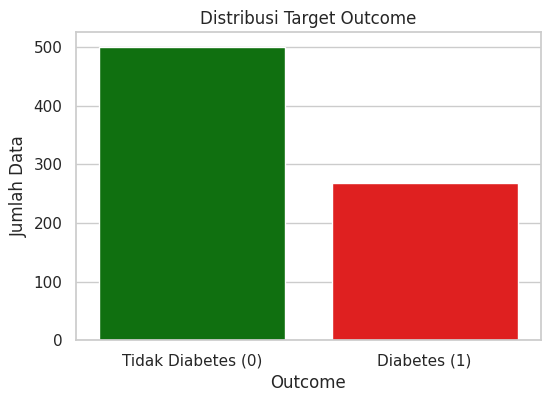

In [24]:
# Visualisasi distribusi target dengan warna berbeda

plt.figure(figsize=(6, 4))
# Menambahkan hue='Outcome' dan menggunakan mapping yang sesuai agar tidak error
sns.countplot(data=df, x='Outcome', hue='Outcome', palette={0: 'green', 1: 'red'}, legend=False)
plt.title('Distribusi Target Outcome')
plt.xlabel('Outcome')
plt.ylabel('Jumlah Data')
plt.xticks([0, 1], ['Tidak Diabetes (0)', 'Diabetes (1)'])
plt.show()

**Interpretasi Sementara Distribusi Target**

Berdasarkan pemeriksaan awal, kelas `Outcome = 0` memiliki jumlah data lebih banyak dibandingkan kelas `Outcome = 1`.

Artinya, dataset imbalance. Kondisi ini perlu diperhatikan pada tahap evaluasi model.

Untuk dataset seperti ini, evaluasi model sebaiknya tidak hanya menggunakan accuracy, tetapi juga menggunakan:

- Precision
- Recall
- F1-score
- Confusion Matrix

Recall pada kelas diabetes juga penting karena model diharapkan mampu mengenali pasien yang benar-benar memiliki indikasi diabetes.

### 6.2 Distribusi Fitur Numerik


Karena seluruh fitur pada dataset berbentuk numerik, visualisasi distribusi dapat membantu untuk menjawab pertanyaan:

1. Apakah data cenderung normal atau skewed?
2. Apakah terdapat nilai ekstrem?
3. Apakah terdapat banyak nilai 0 pada fitur tertentu?
4. Apakah fitur memiliki skala yang berbeda-beda?

In [25]:
# Memisahkan fitur numerik selain target

feature_columns = df.drop(columns=['Outcome']).columns

feature_columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetespedigreeFunction', 'Age'],
      dtype='object')

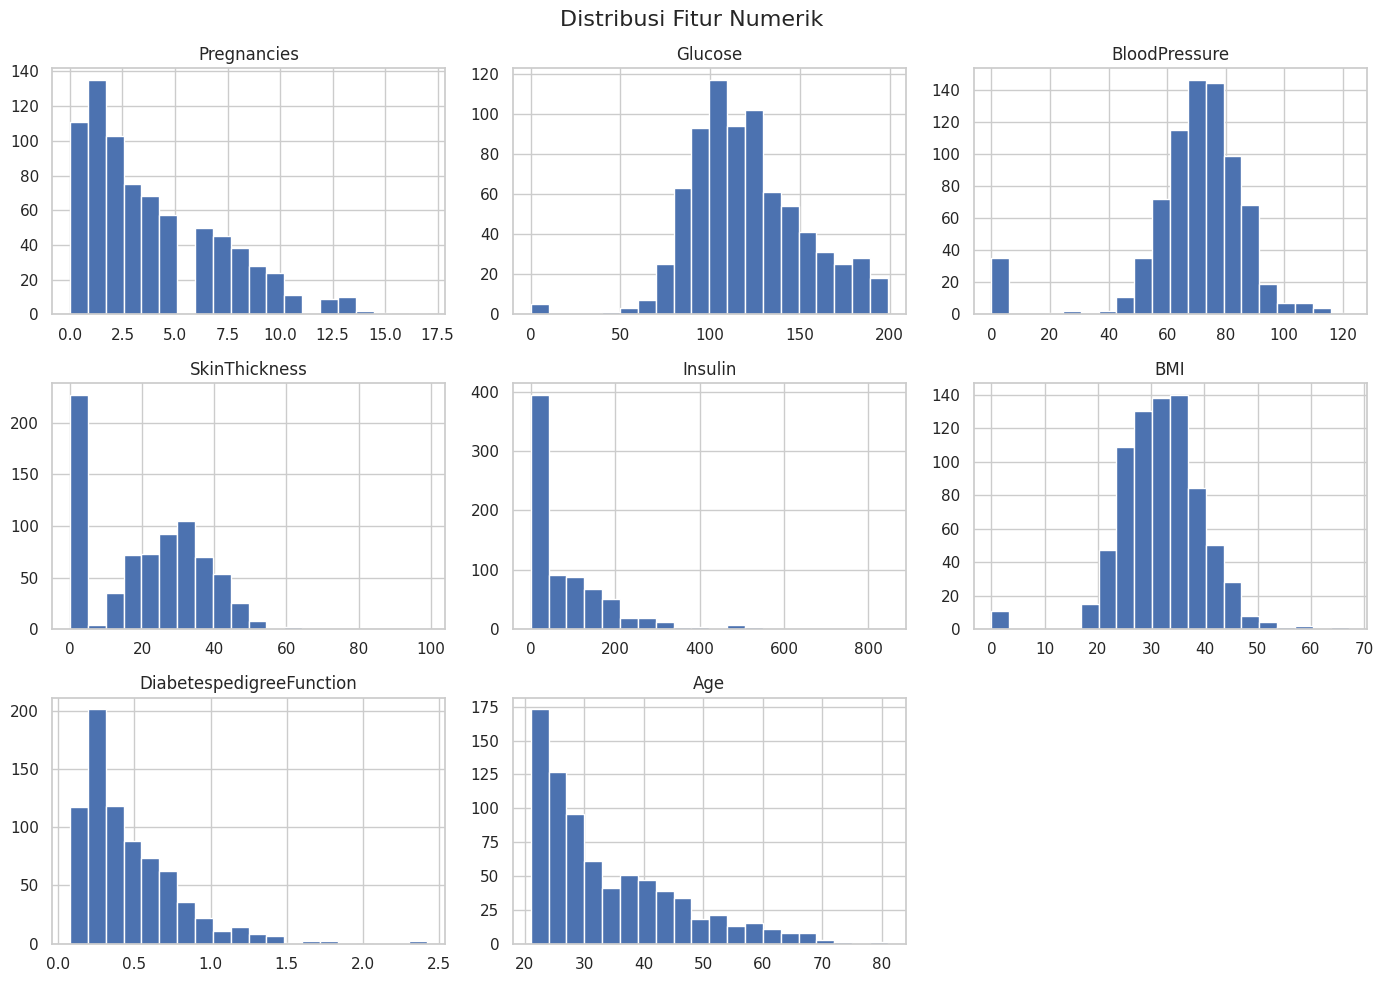

In [26]:
# Visualisasi distribusi setiap fitur numerik

df[feature_columns].hist(figsize=(14, 10), bins=20)
plt.suptitle('Distribusi Fitur Numerik', fontsize=16)
plt.tight_layout()
plt.show()

**Catatan Awal dari Distribusi Fitur**

Dari histogram fitur numerik, beberapa hal yang perlu diperhatikan:

1. Beberapa fitur kemungkinan memiliki distribusi yang tidak normal.
2. Beberapa fitur terlihat skewed atau condong ke salah satu sisi.
3. Fitur seperti `Insulin` dan `SkinThickness` kemungkinan memiliki banyak nilai 0.
4. Setiap fitur memiliki rentang nilai yang berbeda.

Perbedaan skala antar fitur ini nantinya perlu dipertimbangkan pada tahap preprocessing, terutama jika menggunakan model yang sensitif terhadap skala seperti Logistic Regression, SVM, dan KNN.

### 6.3 Distribusi Fitur Berdasarkan Outcome

Selain melihat distribusi fitur secara umum, kita juga perlu membandingkan distribusi setiap fitur berdasarkan kelas target `Outcome`.

Tujuannya adalah untuk melihat apakah pola distribusi fitur berbeda antara:

- `Outcome = 0`, yaitu tidak diabetes.
- `Outcome = 1`, yaitu diabetes.

Jika distribusi suatu fitur terlihat berbeda cukup jelas antar kelas, maka fitur tersebut kemungkinan memiliki kontribusi penting dalam proses klasifikasi.

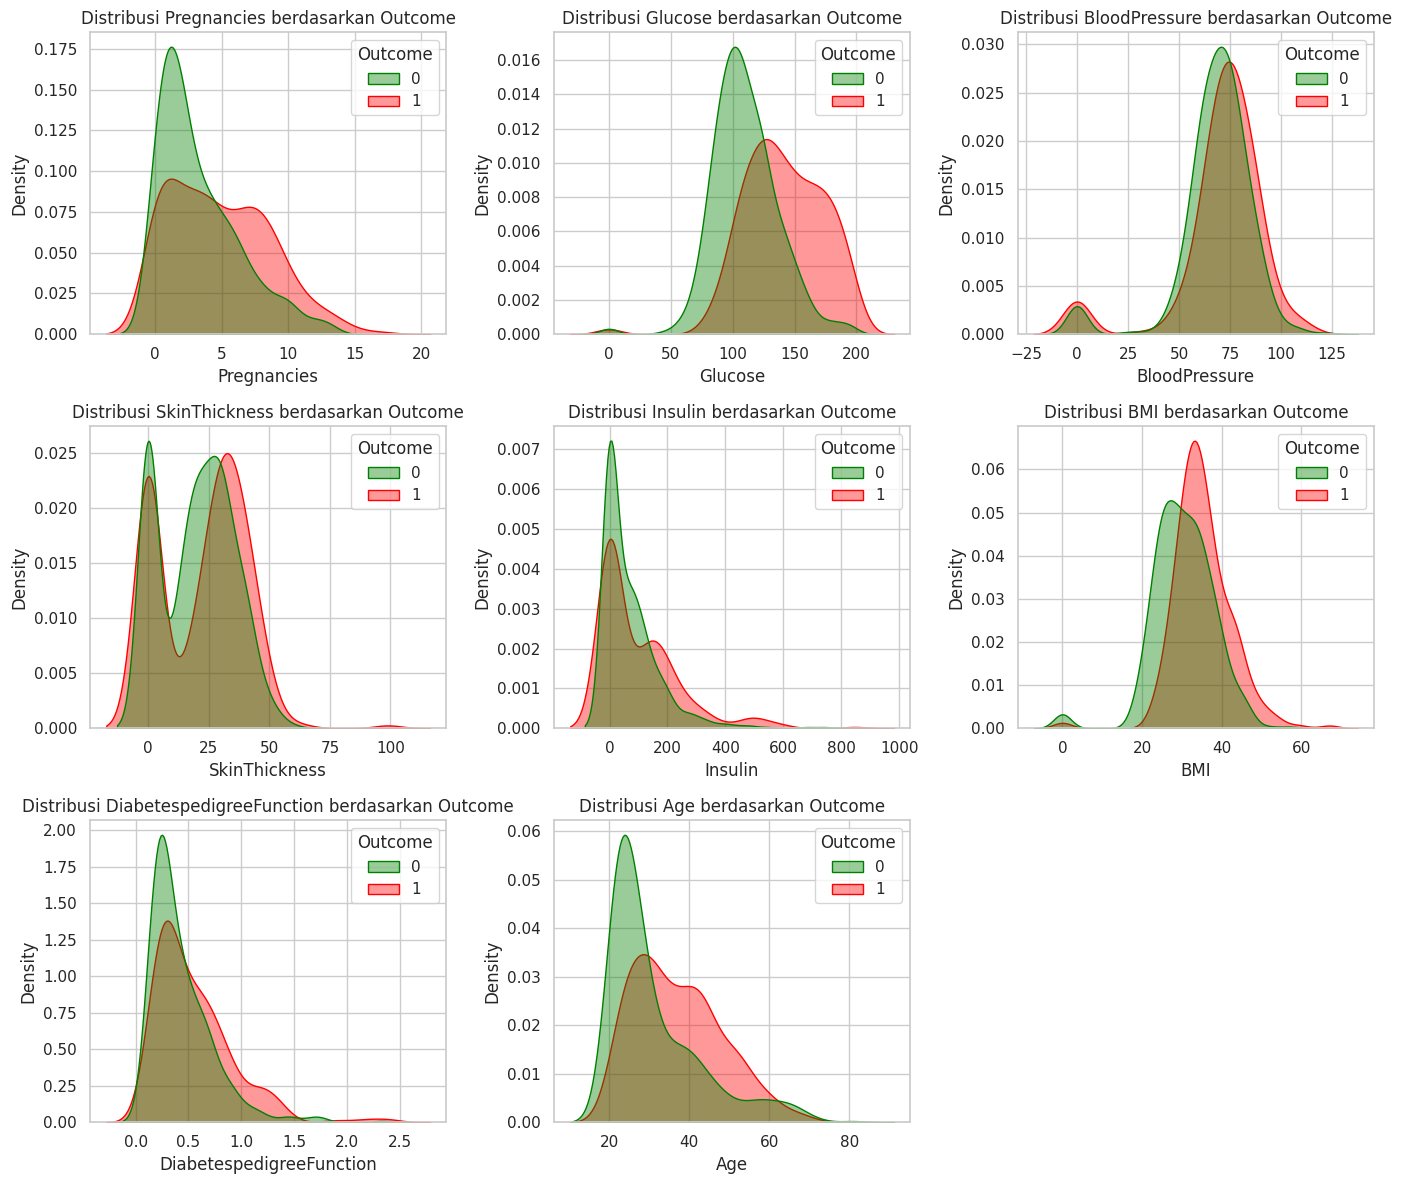

In [55]:
# Visualisasi distribusi setiap fitur berdasarkan Outcome menggunakan KDE Plot

plt.figure(figsize=(14, 12))
# Menentukan palette kustom
custom_palette = {0: 'green', 1: 'red'}

for i, col in enumerate(feature_columns, 1):
    plt.subplot(3, 3, i)
    sns.kdeplot(data=df, x=col, hue='Outcome', fill=True, common_norm=False, alpha=0.4, palette=custom_palette)
    plt.title(f'Distribusi {col} berdasarkan Outcome')

plt.tight_layout()
plt.show()

### 6.4 Deteksi Awal Outlier Menggunakan Boxplot

Boxplot digunakan untuk melihat kemungkinan adanya outlier atau nilai ekstrem pada setiap fitur numerik.

Pada tahap ini, outlier belum akan dihapus. Kita hanya mengidentifikasi terlebih dahulu apakah terdapat nilai yang jauh dari sebaran umum data.

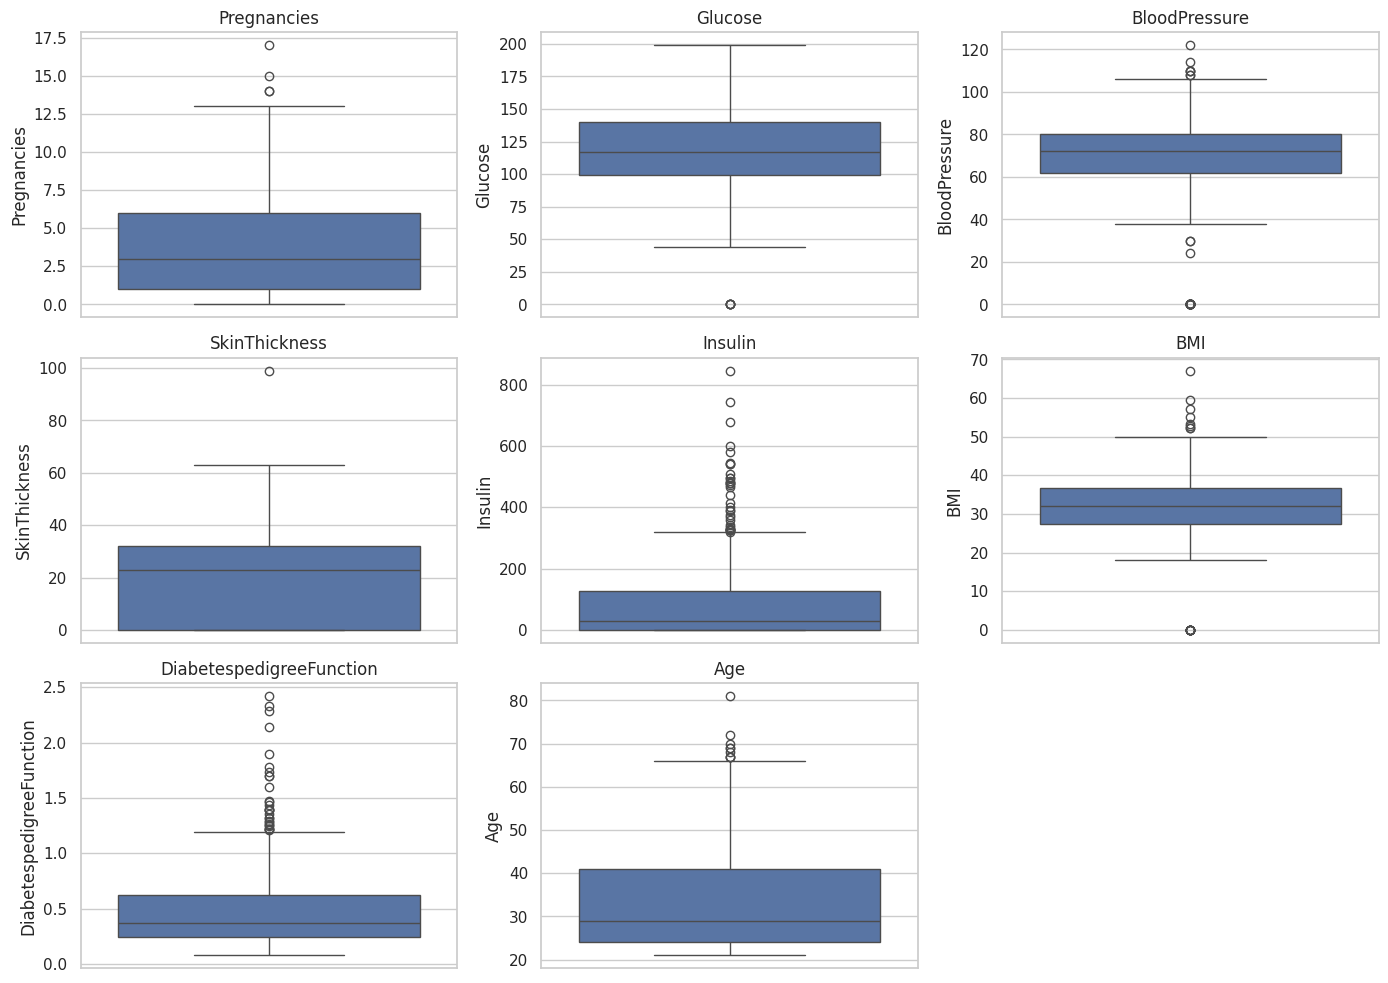

In [27]:
# Visualisasi boxplot setiap fitur numerik

plt.figure(figsize=(14, 10))

for i, col in enumerate(feature_columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

**Catatan Awal dari Boxplot**

Dari boxplot, kita dapat melihat kemungkinan adanya outlier pada beberapa fitur.

Namun, dalam dataset medis, outlier tidak boleh langsung dihapus tanpa analisis lebih lanjut. Nilai ekstrem bisa saja merupakan kondisi pasien yang valid secara medis.

Oleh karena itu, keputusan terhadap outlier akan dilakukan dengan hati-hati pada tahap preprocessing, setelah memahami hubungan fitur terhadap target.

### 6.5 Korelasi Antar Fitur

Korelasi digunakan untuk melihat hubungan linear antar fitur numerik.

Analisis korelasi dapat membantu menjawab beberapa pertanyaan awal:

1. Fitur mana yang memiliki hubungan cukup kuat dengan `Outcome`.
2. Apakah ada fitur yang saling berkorelasi tinggi.
3. Apakah terdapat kemungkinan multikolinearitas antar fitur.

Namun, korelasi hanya menunjukkan hubungan linear. Korelasi rendah tidak selalu berarti fitur tidak penting, karena hubungan antara fitur dan target bisa saja bersifat non-linear.

In [28]:
# Menghitung korelasi antar fitur

correlation_matrix = df.corr()

correlation_matrix

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetespedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


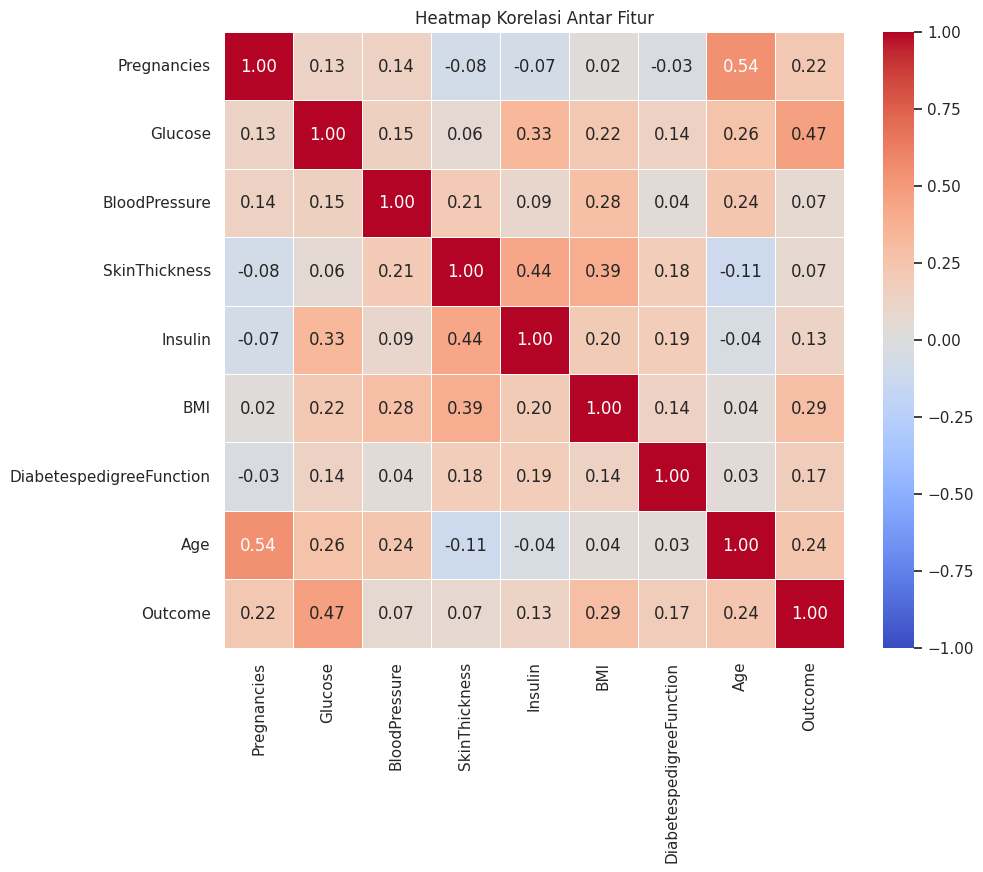

In [31]:
# Visualisasi heatmap korelasi

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', linewidths=0.5, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

### 6.6 Scatter Plot antar Fitur Penting

Scatter plot digunakan untuk melihat hubungan antara dua fitur numerik dan bagaimana pola tersebut berbeda berdasarkan `Outcome`.

Pada tahap ini, kita akan melihat hubungan antara:

- `Glucose` dan `BMI`
- `Glucose` dan `Age`
- `BMI` dan `Age`

Visualisasi ini dapat membantu melihat apakah kombinasi fitur tertentu dapat memisahkan kelas diabetes dan tidak diabetes.

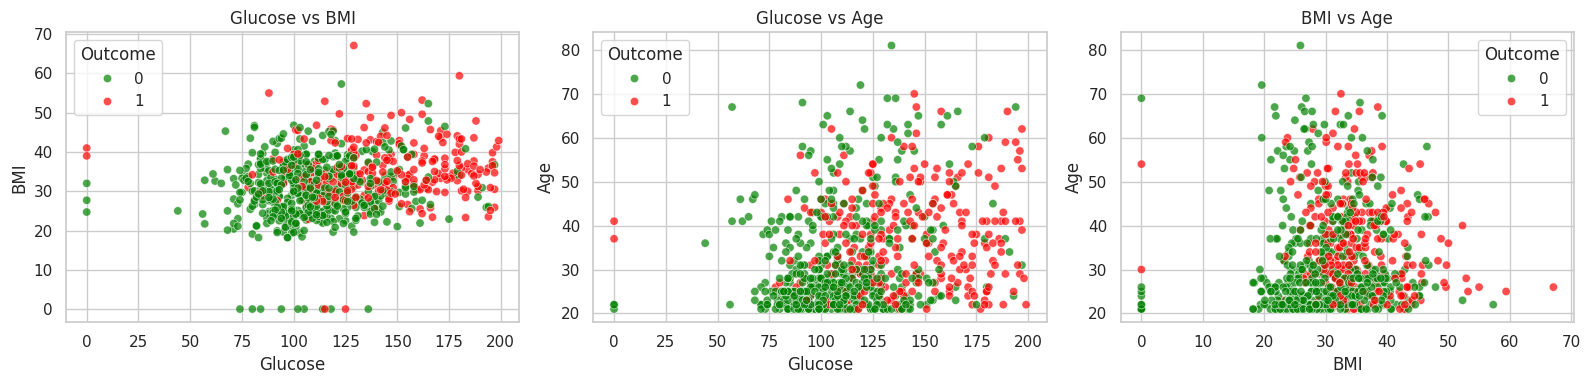

In [54]:
# Scatter plot hubungan antar fitur penting berdasarkan Outcome dengan warna kustom

plt.figure(figsize=(16, 4))
# Menentukan palette: 0 = hijau, 1 = merah
custom_palette = {0: 'green', 1: 'red'}

plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x='Glucose', y='BMI', hue='Outcome', palette=custom_palette, alpha=0.7)
plt.title('Glucose vs BMI')

plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='Glucose', y='Age', hue='Outcome', palette=custom_palette, alpha=0.7)
plt.title('Glucose vs Age')

plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='BMI', y='Age', hue='Outcome', palette=custom_palette, alpha=0.7)
plt.title('BMI vs Age')

plt.tight_layout()
plt.show()

### 6.7 Proporsi Diabetes Berdasarkan Kelompok Nilai Fitur Berbasis Landasan Medis

Pada tahap ini, beberapa fitur numerik akan dikelompokkan atau dilakukan binning berdasarkan kategori yang memiliki landasan medis.

Fitur yang akan dikelompokkan:

1. `Age`

   * Menggunakan kategori usia berdasarkan Kementerian Kesehatan Republik Indonesia.
   * Referensi: [Kemenkes - Kategori Usia](https://ayosehat.kemkes.go.id/kategori-usia)

2. `BMI`

   * Menggunakan kategori Indeks Massa Tubuh atau IMT dewasa.
   * Referensi kategori IMT: [Kemenkes - Buku Saku Pencegahan Anemia pada Ibu Hamil dan Remaja Putri](https://ayosehat.kemkes.go.id/pub/files/197ed157db03c65a4d1be68182613638.pdf)

3. `Glucose`

   * Menggunakan ambang pemeriksaan glukosa 2 jam setelah Oral Glucose Tolerance Test atau OGTT.
   * Referensi ambang OGTT: [American Diabetes Association - Diabetes Diagnosis](https://diabetes.org/about-diabetes/diagnosis)
   * Referensi tambahan: [CDC - Diabetes Testing](https://www.cdc.gov/diabetes/diabetes-testing/index.html)
   * Referensi deskripsi atribut dataset: [Pima Indians Diabetes Dataset Description](https://github.com/jbrownlee/Datasets/blob/master/pima-indians-diabetes.names)

4. `BloodPressure`

   * Menggunakan kategori tekanan darah berdasarkan nilai diastolik.
   * Referensi kategori tekanan darah: [American Heart Association - Understanding Blood Pressure Readings](https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings)
   * Perlu dicatat bahwa dataset hanya memiliki tekanan darah diastolik, bukan sistolik.
   * Referensi deskripsi atribut dataset: [Pima Indians Diabetes Dataset Description](https://github.com/jbrownlee/Datasets/blob/master/pima-indians-diabetes.names)

5. `Pregnancies`

   * Dikelompokkan secara sederhana berdasarkan jumlah kehamilan.
   * Binning ini bukan kategori diagnosis diabetes, tetapi digunakan untuk melihat pola eksploratif.
   * Karena tidak digunakan sebagai kategori diagnosis klinis, pengelompokan `Pregnancies` pada tahap ini bersifat analisis eksploratif, bukan standar medis utama.

Fitur `Insulin`, `SkinThickness`, dan `DiabetespedigreeFunction` tidak dibuat kategori medis utama karena tidak memiliki cut-off klinis universal yang sederhana untuk konteks dataset ini.

Catatan:

* Fitur `Insulin` pada dataset ini merepresentasikan 2-hour serum insulin, sehingga tidak disamakan langsung dengan kategori fasting insulin.
* Fitur `SkinThickness` merepresentasikan triceps skin fold thickness, yang interpretasinya dapat dipengaruhi oleh usia, jenis kelamin, dan populasi.
* Fitur `DiabetespedigreeFunction` merupakan skor turunan pada dataset, bukan kategori klinis umum.
* Referensi deskripsi atribut dataset: [Pima Indians Diabetes Dataset Description](https://github.com/jbrownlee/Datasets/blob/master/pima-indians-diabetes.names)


In [40]:
# Membuat salinan dataframe untuk analisis binning

df_binned = df.copy()

In [41]:
# Binning Age berdasarkan kategori usia Kemenkes

df_binned['Age_Group'] = pd.cut(
    df_binned['Age'],
    bins=[0, 5, 10, 18, 60, np.inf],
    labels=[
        'Balita (<5)',
        'Anak (5-9)',
        'Remaja (10-17)',
        'Dewasa (18-59)',
        'Lansia (>=60)'
    ],
    right=False
)

df_binned['Age_Group'].value_counts().sort_index()

,count
Age_Group,
Balita (<5),0
Anak (5-9),0
Remaja (10-17),0
Dewasa (18-59),736
Lansia (>=60),32


In [42]:
# Binning BMI berdasarkan kategori IMT dewasa

df_binned['BMI_Group'] = pd.cut(
    df_binned['BMI'],
    bins=[-np.inf, 18.5, 25, 27, np.inf],
    labels=[
        'Kurus (<18.5)',
        'Normal (18.5-<25)',
        'BB lebih (25-<27)',
        'Obesitas (>=27)'
    ],
    right=False
)

df_binned['BMI_Group'].value_counts().sort_index()

,count
BMI_Group,
Kurus (<18.5),15
Normal (18.5-<25),102
BB lebih (25-<27),66
Obesitas (>=27),585


In [43]:
# Binning Glucose berdasarkan ambang OGTT 2 jam
# Nilai 0 dipisahkan karena kemungkinan merupakan missing value tersembunyi

df_binned['Glucose_Group'] = pd.cut(
    df_binned['Glucose'],
    bins=[-np.inf, 1, 140, 200, np.inf],
    labels=[
        '0 / indikasi missing',
        'Normal (<140)',
        'Prediabetes (140-199)',
        'Diabetes range (>=200)'
    ],
    right=False
)

df_binned['Glucose_Group'].value_counts().sort_index()

,count
Glucose_Group,
0 / indikasi missing,5
Normal (<140),566
Prediabetes (140-199),197
Diabetes range (>=200),0


In [44]:
# Binning BloodPressure berdasarkan tekanan darah diastolik
# Nilai 0 dipisahkan karena kemungkinan merupakan missing value tersembunyi

df_binned['BloodPressure_Group'] = pd.cut(
    df_binned['BloodPressure'],
    bins=[-np.inf, 1, 80, 90, 120, np.inf],
    labels=[
        '0 / indikasi missing',
        'Normal DBP (<80)',
        'Stage 1 HTN DBP (80-89)',
        'Stage 2 HTN DBP (90-120)',
        'Severe DBP (>120)'
    ],
    right=False
)

df_binned['BloodPressure_Group'].value_counts().sort_index()

,count
BloodPressure_Group,
0 / indikasi missing,35
Normal DBP (<80),528
Stage 1 HTN DBP (80-89),145
Stage 2 HTN DBP (90-120),59
Severe DBP (>120),1


In [45]:
# Binning Pregnancies secara eksploratif
# Ini bukan kategori diagnosis diabetes, hanya pengelompokan jumlah kehamilan

df_binned['Pregnancies_Group'] = pd.cut(
    df_binned['Pregnancies'],
    bins=[-np.inf, 1, 2, 6, np.inf],
    labels=[
        '0 kehamilan',
        '1 kehamilan',
        '2-5 kehamilan',
        '>=6 kehamilan'
    ],
    right=False
)

df_binned['Pregnancies_Group'].value_counts().sort_index()

,count
Pregnancies_Group,
0 kehamilan,111
1 kehamilan,135
2-5 kehamilan,303
>=6 kehamilan,219


#### Menghitung Proporsi Diabetes pada Setiap Kelompok

Setelah fitur dikelompokkan, langkah berikutnya adalah menghitung proporsi `Outcome = 1` atau diabetes pada setiap kelompok.

Analisis ini bertujuan untuk melihat apakah kelompok tertentu memiliki proporsi diabetes yang lebih tinggi dibanding kelompok lainnya.

In [46]:
# Fungsi untuk menghitung proporsi Outcome = 1 pada setiap kelompok fitur

def diabetes_rate_by_group(data, group_col):
    result = (
        data
        .groupby(group_col, observed=False)['Outcome']
        .agg(['count', 'sum', 'mean'])
        .reset_index()
    )

    result.columns = [group_col, 'Jumlah Data', 'Jumlah Diabetes', 'Diabetes Rate']
    result['Diabetes Rate (%)'] = (result['Diabetes Rate'] * 100).round(2)

    return result.drop(columns='Diabetes Rate')

In [47]:
# Menghitung proporsi diabetes untuk setiap fitur hasil binning

age_rate = diabetes_rate_by_group(df_binned, 'Age_Group')
bmi_rate = diabetes_rate_by_group(df_binned, 'BMI_Group')
glucose_rate = diabetes_rate_by_group(df_binned, 'Glucose_Group')
bloodpressure_rate = diabetes_rate_by_group(df_binned, 'BloodPressure_Group')
pregnancies_rate = diabetes_rate_by_group(df_binned, 'Pregnancies_Group')

In [48]:
# Menampilkan proporsi diabetes berdasarkan kelompok usia

age_rate

,Age_Group,Jumlah Data,Jumlah Diabetes,Diabetes Rate (%)
0,Balita (<5),0,0,NaN
1,Anak (5-9),0,0,NaN
2,Remaja (10-17),0,0,NaN
3,Dewasa (18-59),736,259,35.19
4,Lansia (>=60),32,9,28.12


In [49]:
# Menampilkan proporsi diabetes berdasarkan kelompok BMI

bmi_rate

,BMI_Group,Jumlah Data,Jumlah Diabetes,Diabetes Rate (%)
0,Kurus (<18.5),15,2,13.33
1,Normal (18.5-<25),102,7,6.86
2,BB lebih (25-<27),66,9,13.64
3,Obesitas (>=27),585,250,42.74


In [50]:
# Menampilkan proporsi diabetes berdasarkan kelompok Glucose

glucose_rate

,Glucose_Group,Jumlah Data,Jumlah Diabetes,Diabetes Rate (%)
0,0 / indikasi missing,5,2,40.00
1,Normal (<140),566,131,23.14
2,Prediabetes (140-199),197,135,68.53
3,Diabetes range (>=200),0,0,NaN


In [51]:
# Menampilkan proporsi diabetes berdasarkan kelompok Glucose

glucose_rate

,Glucose_Group,Jumlah Data,Jumlah Diabetes,Diabetes Rate (%)
0,0 / indikasi missing,5,2,40.00
1,Normal (<140),566,131,23.14
2,Prediabetes (140-199),197,135,68.53
3,Diabetes range (>=200),0,0,NaN


In [52]:
# Menampilkan proporsi diabetes berdasarkan kelompok Pregnancies

pregnancies_rate

,Pregnancies_Group,Jumlah Data,Jumlah Diabetes,Diabetes Rate (%)
0,0 kehamilan,111,38,34.23
1,1 kehamilan,135,29,21.48
2,2-5 kehamilan,303,90,29.70
3,>=6 kehamilan,219,111,50.68


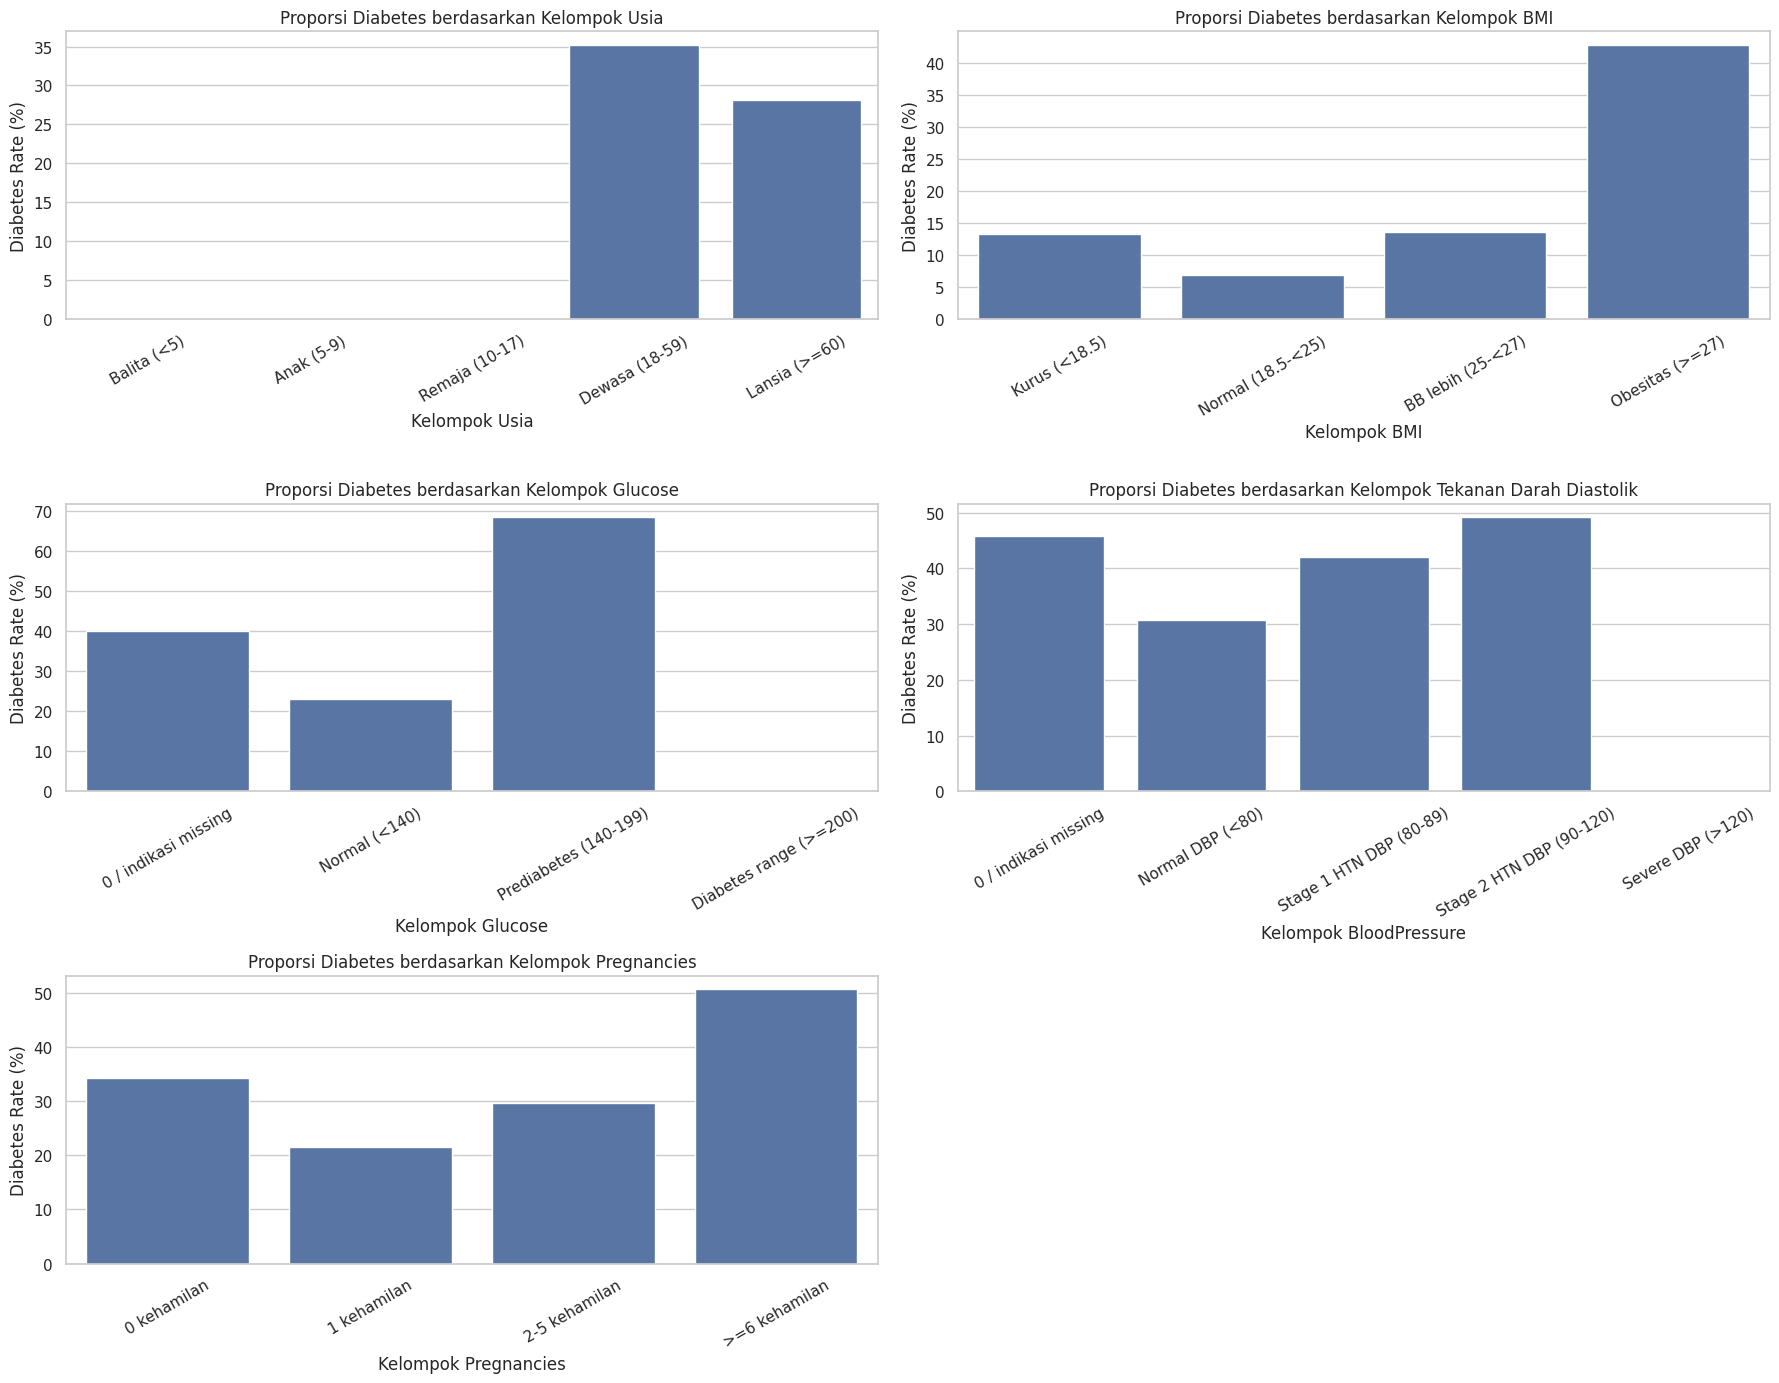

In [53]:
# Visualisasi proporsi diabetes berdasarkan kelompok fitur

plt.figure(figsize=(18, 14))

plt.subplot(3, 2, 1)
sns.barplot(data=age_rate, x='Age_Group', y='Diabetes Rate (%)')
plt.title('Proporsi Diabetes berdasarkan Kelompok Usia')
plt.xlabel('Kelompok Usia')
plt.ylabel('Diabetes Rate (%)')
plt.xticks(rotation=30)

plt.subplot(3, 2, 2)
sns.barplot(data=bmi_rate, x='BMI_Group', y='Diabetes Rate (%)')
plt.title('Proporsi Diabetes berdasarkan Kelompok BMI')
plt.xlabel('Kelompok BMI')
plt.ylabel('Diabetes Rate (%)')
plt.xticks(rotation=30)

plt.subplot(3, 2, 3)
sns.barplot(data=glucose_rate, x='Glucose_Group', y='Diabetes Rate (%)')
plt.title('Proporsi Diabetes berdasarkan Kelompok Glucose')
plt.xlabel('Kelompok Glucose')
plt.ylabel('Diabetes Rate (%)')
plt.xticks(rotation=30)

plt.subplot(3, 2, 4)
sns.barplot(data=bloodpressure_rate, x='BloodPressure_Group', y='Diabetes Rate (%)')
plt.title('Proporsi Diabetes berdasarkan Kelompok Tekanan Darah Diastolik')
plt.xlabel('Kelompok BloodPressure')
plt.ylabel('Diabetes Rate (%)')
plt.xticks(rotation=30)

plt.subplot(3, 2, 5)
sns.barplot(data=pregnancies_rate, x='Pregnancies_Group', y='Diabetes Rate (%)')
plt.title('Proporsi Diabetes berdasarkan Kelompok Pregnancies')
plt.xlabel('Kelompok Pregnancies')
plt.ylabel('Diabetes Rate (%)')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Analisis Tambahan Nilai 0 pada Fitur Insulin

Berdasarkan visualisasi distribusi `Insulin` terhadap `Outcome`, terlihat bahwa banyak data memiliki nilai `Insulin = 0`.

Hal ini perlu dianalisis secara hati-hati. Secara konteks medis, nilai insulin yang sangat rendah dapat terjadi pada kondisi tertentu, misalnya pada diabetes tipe 1. Namun, pada dataset ini, nilai `Insulin = 0` muncul dalam jumlah sangat besar dan juga banyak ditemukan pada pasien dengan `Outcome = 0` atau tidak diabetes.

Kondisi tersebut menunjukkan bahwa nilai `Insulin = 0` kemungkinan besar bukan merepresentasikan kadar insulin biologis yang sebenarnya, melainkan data yang tidak tercatat atau missing value yang dikodekan sebagai angka 0.

Oleh karena itu, pada tahap preprocessing, nilai 0 pada fitur `Insulin` sebaiknya diperlakukan sebagai kandidat missing value tersembunyi.

In [56]:
# Mengecek jumlah data dengan Insulin = 0 berdasarkan Outcome

insulin_zero_by_outcome = (
    df[df['Insulin'] == 0]
    .groupby('Outcome')
    .size()
    .reset_index(name='Jumlah Insulin = 0')
)

insulin_zero_by_outcome

,Outcome,Jumlah Insulin = 0
0,0,236
1,1,138


In [57]:
# Mengecek persentase Insulin = 0 pada masing-masing kelas Outcome

insulin_zero_percentage = (
    df
    .groupby('Outcome')['Insulin']
    .apply(lambda x: (x == 0).mean() * 100)
    .reset_index(name='Persentase Insulin = 0 (%)')
)

insulin_zero_percentage['Persentase Insulin = 0 (%)'] = insulin_zero_percentage['Persentase Insulin = 0 (%)'].round(2)

insulin_zero_percentage

,Outcome,Persentase Insulin = 0 (%)
0,0,47.20
1,1,51.49


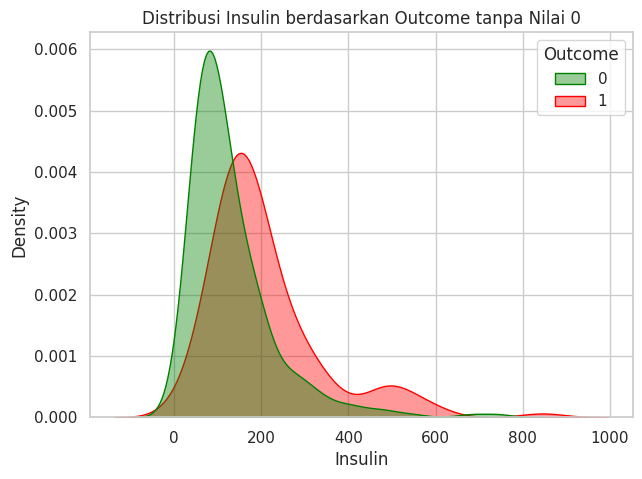

In [59]:
# Membandingkan distribusi Insulin tanpa nilai 0

df_insulin_nonzero = df[df['Insulin'] > 0]

plt.figure(figsize=(7, 5))
# Menerapkan palette kustom
custom_palette = {0: 'green', 1: 'red'}

sns.kdeplot(
    data=df_insulin_nonzero,
    x='Insulin',
    hue='Outcome',
    fill=True,
    common_norm=False,
    alpha=0.4,
    palette=custom_palette
)

plt.title('Distribusi Insulin berdasarkan Outcome tanpa Nilai 0')
plt.xlabel('Insulin')
plt.ylabel('Density')
plt.show()

## Ringkasan Hasil Exploratory Data Analysis

Berdasarkan hasil Exploratory Data Analysis yang telah dilakukan, diperoleh beberapa temuan penting sebagai berikut.

Pertama, distribusi target `Outcome` menunjukkan bahwa dataset tidak sepenuhnya seimbang. Kelas `Outcome = 0` atau tidak diabetes memiliki jumlah data lebih banyak dibandingkan kelas `Outcome = 1` atau diabetes. Kondisi ini menunjukkan adanya class imbalance, sehingga pada tahap evaluasi model nanti tidak cukup hanya menggunakan accuracy. Metrik seperti precision, recall, F1-score, dan confusion matrix perlu digunakan agar performa model dapat dievaluasi secara lebih menyeluruh, terutama dalam mendeteksi kelas diabetes.

Kedua, seluruh fitur input pada dataset berbentuk numerik. Namun, distribusi setiap fitur tidak selalu normal. Beberapa fitur seperti `Pregnancies`, `Insulin`, `DiabetespedigreeFunction`, dan `Age` terlihat cenderung skewed ke kanan. Selain itu, fitur seperti `SkinThickness` dan `Insulin` menunjukkan banyak nilai 0, yang kemungkinan bukan nilai medis yang valid, melainkan missing value tersembunyi.

Ketiga, hasil distribusi fitur berdasarkan `Outcome` menunjukkan bahwa beberapa fitur memiliki pola yang berbeda antara pasien tidak diabetes dan diabetes. Fitur `Glucose` terlihat memiliki perbedaan distribusi paling jelas, di mana kelompok diabetes cenderung memiliki nilai glukosa yang lebih tinggi. Fitur `BMI`, `Age`, `Pregnancies`, dan `DiabetespedigreeFunction` juga menunjukkan kecenderungan nilai yang lebih tinggi pada kelompok diabetes, meskipun distribusinya masih saling tumpang tindih antar kelas.

Keempat, hasil boxplot menunjukkan adanya outlier pada beberapa fitur, terutama `Pregnancies`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetespedigreeFunction`, dan `Age`. Namun, karena dataset ini merupakan dataset medis, outlier tidak boleh langsung dihapus. Nilai ekstrem dapat saja merepresentasikan kondisi pasien yang valid. Oleh karena itu, penanganan outlier perlu dilakukan secara hati-hati pada tahap preprocessing.

Kelima, hasil heatmap korelasi menunjukkan bahwa fitur dengan korelasi paling tinggi terhadap `Outcome` adalah `Glucose`, diikuti oleh `BMI`, `Age`, `Pregnancies`, `DiabetespedigreeFunction`, dan `Insulin`. Fitur `BloodPressure` dan `SkinThickness` memiliki korelasi linear yang relatif rendah terhadap target. Namun, korelasi rendah tidak selalu berarti fitur tidak berguna, karena hubungan antar fitur dan target bisa saja bersifat non-linear.

Keenam, scatter plot menunjukkan bahwa kelas diabetes dan tidak diabetes masih banyak saling tumpang tindih. Meskipun begitu, pasien dengan `Outcome = 1` cenderung lebih banyak muncul pada area dengan nilai `Glucose`, `BMI`, dan `Age` yang lebih tinggi. Hal ini menunjukkan bahwa pemisahan kelas kemungkinan tidak cukup hanya mengandalkan satu fitur, tetapi membutuhkan kombinasi beberapa fitur.

Ketujuh, hasil binning berbasis landasan medis memberikan gambaran yang lebih mudah diinterpretasikan. Pada kelompok `BMI`, proporsi diabetes terlihat lebih tinggi pada kelompok obesitas. Pada kelompok `Glucose`, proporsi diabetes meningkat pada kelompok prediabetes dibandingkan kelompok normal. Pada kelompok `BloodPressure`, proporsi diabetes terlihat lebih tinggi pada kategori tekanan darah diastolik yang lebih tinggi, meskipun interpretasinya harus hati-hati karena dataset hanya memiliki nilai tekanan darah diastolik. Pada kelompok `Pregnancies`, proporsi diabetes terlihat lebih tinggi pada kelompok dengan jumlah kehamilan yang lebih banyak. Untuk `Age`, hanya kelompok dewasa dan lansia yang muncul karena usia minimum pada dataset adalah 21 tahun.

Secara keseluruhan, hasil EDA menunjukkan bahwa dataset ini memiliki beberapa karakteristik penting yang perlu diperhatikan sebelum modeling, yaitu adanya class imbalance, distribusi fitur yang tidak selalu normal, outlier pada beberapa fitur, serta nilai 0 yang kemungkinan merupakan missing value tersembunyi pada beberapa fitur medis.

Berdasarkan temuan tersebut, tahap preprocessing perlu mempertimbangkan beberapa hal berikut:

1. Nilai 0 pada `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, dan `BMI` perlu ditangani sebagai kemungkinan missing value tersembunyi.
2. Imputasi sebaiknya dilakukan setelah train-test split agar tidak menyebabkan data leakage.
3. Fitur numerik perlu dipertimbangkan untuk scaling, terutama jika menggunakan model yang sensitif terhadap skala seperti Logistic Regression, SVM, dan KNN.
4. Outlier perlu dianalisis secara hati-hati dan tidak langsung dihapus.
5. Evaluasi model perlu menggunakan metrik selain accuracy karena distribusi target tidak sepenuhnya seimbang.
6. Model non-linear seperti Decision Tree, Random Forest, atau Gradient Boosting dapat dipertimbangkan karena pola antar kelas terlihat saling tumpang tindih dan tidak sepenuhnya linear.

Dengan demikian, tahap berikutnya adalah preprocessing data untuk menangani nilai 0 yang tidak realistis, melakukan pembagian data training dan testing, serta menyiapkan pipeline sebelum masuk ke tahap modeling.


## 7. Data Preprocessing

Tahap preprocessing dilakukan untuk menyiapkan dataset sebelum masuk ke tahap modeling.

Berdasarkan hasil EDA, beberapa hal penting yang perlu ditangani adalah:

1. Memisahkan fitur dan target.
2. Membagi data menjadi training set dan testing set.
3. Menangani nilai 0 yang kemungkinan merupakan missing value tersembunyi.
4. Melakukan imputasi nilai missing.
5. Melakukan feature scaling.
6. Menyiapkan versi data untuk beberapa jenis model.

Catatan penting:

Preprocessing yang mempelajari statistik data, seperti imputasi median dan scaling, harus dilakukan berdasarkan data training saja. Data testing tidak boleh ikut digunakan dalam proses fitting preprocessing agar tidak terjadi data leakage.

In [60]:
# Import library untuk preprocessing

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

### 7.1 Memisahkan Fitur dan Target

Kolom `Outcome` digunakan sebagai target klasifikasi.

Fitur input adalah seluruh kolom selain `Outcome`.

In [61]:
# Memisahkan fitur dan target

X = df.drop(columns=['Outcome'])
y = df['Outcome']

print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)

Ukuran X: (768, 8)
Ukuran y: (768,)


In [62]:
# Melihat nama fitur yang digunakan

X.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetespedigreeFunction', 'Age'],
      dtype='object')

### 7.2 Train-Test Split

Dataset dibagi menjadi data training dan data testing.

Pada tahap ini digunakan stratified split agar proporsi kelas `Outcome = 0` dan `Outcome = 1` tetap terjaga pada data training dan testing.

In [63]:
# Membagi dataset menjadi training set dan testing set

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (614, 8)
X_test : (154, 8)
y_train: (614,)
y_test : (154,)


In [64]:
# Mengecek distribusi target pada train dan test set

split_distribution = pd.DataFrame({
    'Train Count': y_train.value_counts().sort_index(),
    'Train Percentage (%)': (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
    'Test Count': y_test.value_counts().sort_index(),
    'Test Percentage (%)': (y_test.value_counts(normalize=True).sort_index() * 100).round(2)
})

split_distribution

,Train Count,Train Percentage (%),Test Count,Test Percentage (%)
Outcome,,,,
0,400,65.15,100,64.94
1,214,34.85,54,35.06


### 7.3 Menangani Nilai 0 sebagai Missing Value Tersembunyi

Berdasarkan hasil EDA, nilai 0 pada beberapa fitur medis kemungkinan tidak merepresentasikan nilai sebenarnya, tetapi data yang tidak tercatat.

Kolom yang akan diperlakukan sebagai kandidat missing value tersembunyi adalah:

- `Glucose`
- `BloodPressure`
- `SkinThickness`
- `Insulin`
- `BMI`

Nilai 0 pada `Pregnancies` tidak diubah karena masih valid secara konteks. Seseorang bisa saja memiliki 0 kehamilan.

Nilai 0 pada `Outcome` juga valid karena merupakan label kelas.

In [65]:
# Kolom yang nilai 0-nya akan diperlakukan sebagai missing value tersembunyi

invalid_zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

invalid_zero_columns

['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [66]:
# Mengecek jumlah nilai 0 pada train dan test set sebelum penanganan

zero_train_test_summary = pd.DataFrame({
    'Zero in X_train': (X_train[invalid_zero_columns] == 0).sum(),
    'Zero in X_test': (X_test[invalid_zero_columns] == 0).sum()
})

zero_train_test_summary

,Zero in X_train,Zero in X_test
Glucose,4,1
BloodPressure,23,12
SkinThickness,175,52
Insulin,290,84
BMI,9,2


### 7.4 Membuat Missing Indicator

Sebelum nilai 0 diubah menjadi NaN, dibuat fitur tambahan berupa indikator apakah suatu data awalnya memiliki nilai 0 pada fitur medis tertentu.

Tujuannya adalah agar informasi bahwa suatu nilai awalnya tidak tercatat tetap tersimpan.

Contoh:

- `Insulin_was_zero = 1` berarti nilai `Insulin` pada data tersebut awalnya 0.
- `Insulin_was_zero = 0` berarti nilai `Insulin` pada data tersebut bukan 0.

Strategi ini berguna karena pola missing value pada dataset medis bisa saja memiliki informasi terhadap target.

In [67]:
# Membuat salinan data train dan test sebelum preprocessing

X_train_prep = X_train.copy()
X_test_prep = X_test.copy()

# Membuat missing indicator untuk kolom yang memiliki nilai 0 tidak realistis

for col in invalid_zero_columns:
    X_train_prep[f'{col}_was_zero'] = (X_train_prep[col] == 0).astype(int)
    X_test_prep[f'{col}_was_zero'] = (X_test_prep[col] == 0).astype(int)

X_train_prep.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Glucose_was_zero,BloodPressure_was_zero,SkinThickness_was_zero,Insulin_was_zero,BMI_was_zero
353,1,90,62,12,43,27.2,0.580,24,0,0,0,0,0
711,5,126,78,27,22,29.6,0.439,40,0,0,0,0,0
373,2,105,58,40,94,34.9,0.225,25,0,0,0,0,0
46,1,146,56,0,0,29.7,0.564,29,0,0,1,1,0
682,0,95,64,39,105,44.6,0.366,22,0,0,0,0,0


In [70]:
# Mengubah nilai 0 menjadi NaN hanya pada kolom medis tertentu

X_train_prep[invalid_zero_columns] = X_train_prep[invalid_zero_columns].replace(0, np.nan)
X_test_prep[invalid_zero_columns] = X_test_prep[invalid_zero_columns].replace(0, np.nan)

In [71]:
# Mengecek missing value setelah nilai 0 diubah menjadi NaN

missing_after_zero_replacement = pd.DataFrame({
    'Missing in X_train': X_train_prep.isnull().sum(),
    'Missing in X_test': X_test_prep.isnull().sum()
})

missing_after_zero_replacement[
    missing_after_zero_replacement.sum(axis=1) > 0
]

,Missing in X_train,Missing in X_test
Glucose,4,1
BloodPressure,23,12
SkinThickness,175,52
Insulin,290,84
BMI,9,2


### 7.5 Imputasi Missing Value

Setelah nilai 0 pada fitur medis tertentu diubah menjadi NaN, tahap berikutnya adalah melakukan imputasi.

Strategi imputasi yang digunakan adalah median.

Alasan menggunakan median:

1. Median lebih robust terhadap outlier.
2. Beberapa fitur memiliki distribusi yang skewed.
3. Dataset medis dapat memiliki nilai ekstrem yang tidak boleh langsung dihapus.

Imputer hanya di-fit pada data training, kemudian digunakan untuk mentransformasi data training dan testing.

In [72]:
# Melakukan imputasi median

imputer = SimpleImputer(strategy='median')

X_train_imputed_array = imputer.fit_transform(X_train_prep)
X_test_imputed_array = imputer.transform(X_test_prep)

# Mengubah hasil imputasi kembali menjadi DataFrame

X_train_imputed = pd.DataFrame(
    X_train_imputed_array,
    columns=X_train_prep.columns,
    index=X_train_prep.index
)

X_test_imputed = pd.DataFrame(
    X_test_imputed_array,
    columns=X_test_prep.columns,
    index=X_test_prep.index
)

In [73]:
# Melihat nilai median yang digunakan untuk imputasi

imputation_values = pd.DataFrame({
    'Fitur': X_train_prep.columns,
    'Nilai Median dari X_train': imputer.statistics_
})

imputation_values[imputation_values['Fitur'].isin(invalid_zero_columns)]

,Fitur,Nilai Median dari X_train
1,Glucose,117.0
2,BloodPressure,72.0
3,SkinThickness,29.0
4,Insulin,125.0
5,BMI,32.4


In [74]:
# Mengecek apakah masih ada missing value setelah imputasi

print("Total missing value pada X_train_imputed:", X_train_imputed.isnull().sum().sum())
print("Total missing value pada X_test_imputed :", X_test_imputed.isnull().sum().sum())

Total missing value pada X_train_imputed: 0
Total missing value pada X_test_imputed : 0


### 7.6 Feature Scaling

Feature scaling dilakukan menggunakan StandardScaler.

StandardScaler mengubah fitur sehingga memiliki rata-rata mendekati 0 dan standar deviasi mendekati 1.

Scaling penting untuk model yang sensitif terhadap skala fitur, seperti:

- Logistic Regression
- SVM
- KNN
- Neural Network sederhana

Namun, model berbasis tree seperti Decision Tree, Random Forest, dan Gradient Boosting umumnya tidak wajib menggunakan scaling.

In [75]:
# Melakukan feature scaling

scaler = StandardScaler()

X_train_scaled_array = scaler.fit_transform(X_train_imputed)
X_test_scaled_array = scaler.transform(X_test_imputed)

# Mengubah hasil scaling kembali menjadi DataFrame

X_train_scaled = pd.DataFrame(
    X_train_scaled_array,
    columns=X_train_imputed.columns,
    index=X_train_imputed.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled_array,
    columns=X_test_imputed.columns,
    index=X_test_imputed.index
)

In [76]:
# Melihat contoh data setelah scaling

X_train_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Glucose_was_zero,BloodPressure_was_zero,SkinThickness_was_zero,Insulin_was_zero,BMI_was_zero
353,-0.851355,-1.056427,-0.826740,-1.918187,-1.203361,-0.769694,0.310794,-0.792169,-0.080978,-0.197274,-0.631374,-0.946077,-0.121967
711,0.356576,0.144399,0.477772,-0.229874,-1.470195,-0.417714,-0.116439,0.561034,-0.080978,-0.197274,-0.631374,-0.946077,-0.121967
373,-0.549372,-0.556083,-1.152868,1.233330,-0.555335,0.359576,-0.764862,-0.707594,-0.080978,-0.197274,-0.631374,-0.946077,-0.121967
46,-0.851355,0.811525,-1.315932,-0.004766,-0.161437,-0.403048,0.262314,-0.369293,-0.080978,-0.197274,1.583847,1.056996,-0.121967
682,-1.153338,-0.889646,-0.663676,1.120776,-0.415565,1.782163,-0.337630,-0.961320,-0.080978,-0.197274,-0.631374,-0.946077,-0.121967


In [77]:
# Mengecek ringkasan rata-rata dan standar deviasi setelah scaling pada data training

scaling_check = pd.DataFrame({
    'Mean': X_train_scaled.mean().round(3),
    'Std': X_train_scaled.std().round(3)
})

scaling_check

,Mean,Std
Pregnancies,-0.0,1.001
Glucose,-0.0,1.001
BloodPressure,0.0,1.001
SkinThickness,-0.0,1.001
Insulin,-0.0,1.001
BMI,0.0,1.001
DiabetespedigreeFunction,-0.0,1.001
Age,-0.0,1.001
Glucose_was_zero,0.0,1.001
BloodPressure_was_zero,-0.0,1.001


### 7.7 Menyiapkan Versi Data untuk Modeling

Setelah preprocessing, disiapkan dua versi data:

1. Data hasil imputasi tanpa scaling
   - Cocok untuk model berbasis tree.
   - Contoh: Decision Tree, Random Forest, Gradient Boosting.

2. Data hasil imputasi dengan scaling
   - Cocok untuk model yang sensitif terhadap skala.
   - Contoh: Logistic Regression, SVM, KNN.

Dengan menyimpan dua versi data, proses modeling nanti bisa lebih fleksibel.

In [79]:
# Versi data untuk model berbasis tree

X_train_tree = X_train_imputed.copy()
X_test_tree = X_test_imputed.copy()

# Versi data untuk model yang membutuhkan scaling

X_train_scaled_model = X_train_scaled.copy()
X_test_scaled_model = X_test_scaled.copy()

print("Data untuk model tree:")
print("X_train_tree:", X_train_tree.shape)
print("X_test_tree :", X_test_tree.shape)

print("\nData untuk model berbasis scaling:")
print("X_train_scaled_model:", X_train_scaled_model.shape)
print("X_test_scaled_model :", X_test_scaled_model.shape)

Data untuk model tree:
X_train_tree: (614, 13)
X_test_tree : (154, 13)

Data untuk model berbasis scaling:
X_train_scaled_model: (614, 13)
X_test_scaled_model : (154, 13)


### Ringkasan Tahap Preprocessing

Pada tahap preprocessing, beberapa langkah telah dilakukan:

1. Fitur dan target dipisahkan.
2. Dataset dibagi menjadi training set dan testing set menggunakan stratified split.
3. Nilai 0 pada `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, dan `BMI` diperlakukan sebagai missing value tersembunyi.
4. Missing indicator dibuat untuk menyimpan informasi apakah suatu nilai awalnya bernilai 0.
5. Nilai 0 pada fitur medis tertentu diubah menjadi NaN.
6. Missing value diimputasi menggunakan median dari data training.
7. Feature scaling dilakukan menggunakan StandardScaler.
8. Dua versi data disiapkan:
   - Data imputed tanpa scaling untuk model berbasis tree.
   - Data imputed dengan scaling untuk model yang sensitif terhadap skala.

Tahap ini dilakukan dengan memperhatikan prinsip pencegahan data leakage. Imputer dan scaler hanya di-fit pada data training, kemudian diterapkan pada data testing.

Setelah preprocessing selesai, tahap berikutnya adalah membangun model baseline untuk klasifikasi diabetes.

## 8. Model Training

Setelah tahap preprocessing selesai, langkah berikutnya adalah melakukan training model.

Pada tahap ini, beberapa model baseline akan dilatih untuk melihat performa awal masing-masing algoritma.

Model yang digunakan dibagi menjadi dua kelompok:

1. Model yang menggunakan data hasil scaling:
   - Logistic Regression
   - K-Nearest Neighbors
   - Support Vector Machine

2. Model berbasis tree yang menggunakan data tanpa scaling:
   - Decision Tree
   - Random Forest
   - Gradient Boosting

Pada tahap ini belum dilakukan hyperparameter tuning. Tujuannya adalah membangun baseline terlebih dahulu.

In [80]:
# Import library model machine learning

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

### 8.1 Menyiapkan Model Baseline

Pada tahap ini, setiap model akan dibuat secara terpisah agar proses training lebih mudah dipahami.

Model yang digunakan:

1. Logistic Regression
2. K-Nearest Neighbors
3. Support Vector Machine
4. Decision Tree
5. Random Forest
6. Gradient Boosting

Model Logistic Regression, KNN, dan SVM menggunakan data hasil scaling.

Model Decision Tree, Random Forest, dan Gradient Boosting menggunakan data tanpa scaling.

In [81]:
# Membuat model Logistic Regression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Membuat model K-Nearest Neighbors

knn_model = KNeighborsClassifier()

# Membuat model Support Vector Machine

svm_model = SVC(
    random_state=42
)

# Membuat model Decision Tree

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Membuat model Random Forest

random_forest_model = RandomForestClassifier(
    random_state=42
)

# Membuat model Gradient Boosting

gradient_boosting_model = GradientBoostingClassifier(
    random_state=42
)

### 8.2 Training Model yang Menggunakan Data Scaling

Model Logistic Regression, KNN, dan SVM dilatih menggunakan data hasil scaling, yaitu `X_train_scaled_model`.

Hal ini dilakukan karena ketiga model tersebut sensitif terhadap perbedaan skala antar fitur.

In [82]:
# Training Logistic Regression

logistic_model.fit(X_train_scaled_model, y_train)

print("Logistic Regression berhasil dilatih.")

Logistic Regression berhasil dilatih.


In [83]:
# Training K-Nearest Neighbors

knn_model.fit(X_train_scaled_model, y_train)

print("KNN berhasil dilatih.")

KNN berhasil dilatih.


In [84]:
# Training Support Vector Machine

svm_model.fit(X_train_scaled_model, y_train)

print("SVM berhasil dilatih.")

SVM berhasil dilatih.


### 8.3 Training Model Berbasis Tree

Model Decision Tree, Random Forest, dan Gradient Boosting dilatih menggunakan data tanpa scaling, yaitu `X_train_tree`.

Model berbasis tree tidak terlalu sensitif terhadap perbedaan skala fitur.

In [85]:
# Training Decision Tree

decision_tree_model.fit(X_train_tree, y_train)

print("Decision Tree berhasil dilatih.")

Decision Tree berhasil dilatih.


In [86]:
# Training Random Forest

random_forest_model.fit(X_train_tree, y_train)

print("Random Forest berhasil dilatih.")

Random Forest berhasil dilatih.


In [87]:
# Training Gradient Boosting

gradient_boosting_model.fit(X_train_tree, y_train)

print("Gradient Boosting berhasil dilatih.")

Gradient Boosting berhasil dilatih.


### 8.4 Sanity Check Performa pada Data Training

Setelah model dilatih, dilakukan pengecekan awal menggunakan data training.

Pengecekan ini bukan evaluasi final. Evaluasi final tetap harus dilakukan pada data testing.

Tujuan sanity check ini adalah untuk melihat apakah model sudah berhasil belajar dari data training.

In [88]:
# Import metrik accuracy untuk sanity check

from sklearn.metrics import accuracy_score

In [89]:
# Prediksi pada data training

y_train_pred_logistic = logistic_model.predict(X_train_scaled_model)
y_train_pred_knn = knn_model.predict(X_train_scaled_model)
y_train_pred_svm = svm_model.predict(X_train_scaled_model)

y_train_pred_decision_tree = decision_tree_model.predict(X_train_tree)
y_train_pred_random_forest = random_forest_model.predict(X_train_tree)
y_train_pred_gradient_boosting = gradient_boosting_model.predict(X_train_tree)

In [90]:
# Menghitung training accuracy setiap model

train_acc_logistic = accuracy_score(y_train, y_train_pred_logistic)
train_acc_knn = accuracy_score(y_train, y_train_pred_knn)
train_acc_svm = accuracy_score(y_train, y_train_pred_svm)

train_acc_decision_tree = accuracy_score(y_train, y_train_pred_decision_tree)
train_acc_random_forest = accuracy_score(y_train, y_train_pred_random_forest)
train_acc_gradient_boosting = accuracy_score(y_train, y_train_pred_gradient_boosting)

In [91]:
# Menampilkan hasil training accuracy dalam bentuk tabel

train_results_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'SVM',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Training Accuracy': [
        train_acc_logistic,
        train_acc_knn,
        train_acc_svm,
        train_acc_decision_tree,
        train_acc_random_forest,
        train_acc_gradient_boosting
    ]
})

train_results_df = train_results_df.sort_values(
    by='Training Accuracy',
    ascending=False
)

train_results_df

,Model,Training Accuracy
4,Random Forest,1.000000
3,Decision Tree,1.000000
5,Gradient Boosting,0.923453
1,KNN,0.837134
2,SVM,0.830619
0,Logistic Regression,0.794788


### Catatan Sementara dari Model Training

Pada tahap ini, semua model baseline telah berhasil dilatih.

Hasil training accuracy hanya digunakan sebagai pengecekan awal, bukan sebagai dasar pemilihan model terbaik.

Jika sebuah model memiliki training accuracy sangat tinggi, belum tentu model tersebut paling baik. Model tersebut bisa saja mengalami overfitting.

Model terbaik baru dapat ditentukan setelah dilakukan evaluasi menggunakan data testing.

Tahap berikutnya adalah model evaluation dengan menggunakan beberapa metrik, yaitu:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Classification Report

## 9. Model Evaluation

Setelah model dilatih, tahap berikutnya adalah mengevaluasi performa model menggunakan data testing.

Evaluasi pada data testing penting karena data testing merepresentasikan data yang belum pernah dilihat model saat training.

Pada tahap ini, metrik evaluasi yang digunakan adalah:

1. Accuracy
2. Precision
3. Recall
4. F1-score
5. Balanced Accuracy
6. Confusion Matrix
7. Classification Report

Karena dataset memiliki ketidakseimbangan kelas, evaluasi tidak hanya berfokus pada accuracy. Recall untuk kelas `Outcome = 1` atau diabetes juga penting karena model diharapkan mampu mendeteksi pasien yang benar-benar terindikasi diabetes.

In [92]:
# Import metrik evaluasi

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

### 9.1 Melakukan Prediksi pada Data Testing

Setiap model akan digunakan untuk melakukan prediksi pada data testing.

Model Logistic Regression, KNN, dan SVM menggunakan `X_test_scaled_model`.

Model Decision Tree, Random Forest, dan Gradient Boosting menggunakan `X_test_tree`.

In [93]:
# Prediksi data testing untuk model yang menggunakan data scaling

y_test_pred_logistic = logistic_model.predict(X_test_scaled_model)
y_test_pred_knn = knn_model.predict(X_test_scaled_model)
y_test_pred_svm = svm_model.predict(X_test_scaled_model)

In [94]:
# Prediksi data testing untuk model berbasis tree

y_test_pred_decision_tree = decision_tree_model.predict(X_test_tree)
y_test_pred_random_forest = random_forest_model.predict(X_test_tree)
y_test_pred_gradient_boosting = gradient_boosting_model.predict(X_test_tree)

### 9.2 Menghitung Metrik Evaluasi

Metrik evaluasi dihitung untuk setiap model.

Penjelasan singkat metrik:

- Accuracy mengukur proporsi prediksi yang benar secara keseluruhan.
- Precision mengukur seberapa banyak prediksi diabetes yang benar-benar diabetes.
- Recall mengukur seberapa banyak pasien diabetes yang berhasil terdeteksi.
- F1-score merupakan rata-rata harmonik antara precision dan recall.
- Balanced accuracy menghitung rata-rata recall dari setiap kelas, sehingga lebih sesuai untuk dataset yang tidak sepenuhnya seimbang.

In [95]:
# Menghitung metrik evaluasi Logistic Regression

accuracy_logistic = accuracy_score(y_test, y_test_pred_logistic)
precision_logistic = precision_score(y_test, y_test_pred_logistic)
recall_logistic = recall_score(y_test, y_test_pred_logistic)
f1_logistic = f1_score(y_test, y_test_pred_logistic)
balanced_accuracy_logistic = balanced_accuracy_score(y_test, y_test_pred_logistic)

In [96]:
# Menghitung metrik evaluasi KNN

accuracy_knn = accuracy_score(y_test, y_test_pred_knn)
precision_knn = precision_score(y_test, y_test_pred_knn)
recall_knn = recall_score(y_test, y_test_pred_knn)
f1_knn = f1_score(y_test, y_test_pred_knn)
balanced_accuracy_knn = balanced_accuracy_score(y_test, y_test_pred_knn)

In [97]:
# Menghitung metrik evaluasi SVM

accuracy_svm = accuracy_score(y_test, y_test_pred_svm)
precision_svm = precision_score(y_test, y_test_pred_svm)
recall_svm = recall_score(y_test, y_test_pred_svm)
f1_svm = f1_score(y_test, y_test_pred_svm)
balanced_accuracy_svm = balanced_accuracy_score(y_test, y_test_pred_svm)

In [98]:
# Menghitung metrik evaluasi Decision Tree

accuracy_decision_tree = accuracy_score(y_test, y_test_pred_decision_tree)
precision_decision_tree = precision_score(y_test, y_test_pred_decision_tree)
recall_decision_tree = recall_score(y_test, y_test_pred_decision_tree)
f1_decision_tree = f1_score(y_test, y_test_pred_decision_tree)
balanced_accuracy_decision_tree = balanced_accuracy_score(y_test, y_test_pred_decision_tree)

In [99]:
# Menghitung metrik evaluasi Random Forest

accuracy_random_forest = accuracy_score(y_test, y_test_pred_random_forest)
precision_random_forest = precision_score(y_test, y_test_pred_random_forest)
recall_random_forest = recall_score(y_test, y_test_pred_random_forest)
f1_random_forest = f1_score(y_test, y_test_pred_random_forest)
balanced_accuracy_random_forest = balanced_accuracy_score(y_test, y_test_pred_random_forest)

In [100]:
# Menghitung metrik evaluasi Gradient Boosting

accuracy_gradient_boosting = accuracy_score(y_test, y_test_pred_gradient_boosting)
precision_gradient_boosting = precision_score(y_test, y_test_pred_gradient_boosting)
recall_gradient_boosting = recall_score(y_test, y_test_pred_gradient_boosting)
f1_gradient_boosting = f1_score(y_test, y_test_pred_gradient_boosting)
balanced_accuracy_gradient_boosting = balanced_accuracy_score(y_test, y_test_pred_gradient_boosting)

In [101]:
# Membuat tabel perbandingan metrik evaluasi

evaluation_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'SVM',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Accuracy': [
        accuracy_logistic,
        accuracy_knn,
        accuracy_svm,
        accuracy_decision_tree,
        accuracy_random_forest,
        accuracy_gradient_boosting
    ],
    'Precision': [
        precision_logistic,
        precision_knn,
        precision_svm,
        precision_decision_tree,
        precision_random_forest,
        precision_gradient_boosting
    ],
    'Recall': [
        recall_logistic,
        recall_knn,
        recall_svm,
        recall_decision_tree,
        recall_random_forest,
        recall_gradient_boosting
    ],
    'F1-Score': [
        f1_logistic,
        f1_knn,
        f1_svm,
        f1_decision_tree,
        f1_random_forest,
        f1_gradient_boosting
    ],
    'Balanced Accuracy': [
        balanced_accuracy_logistic,
        balanced_accuracy_knn,
        balanced_accuracy_svm,
        balanced_accuracy_decision_tree,
        balanced_accuracy_random_forest,
        balanced_accuracy_gradient_boosting
    ]
})

evaluation_results

,Model,Accuracy,Precision,Recall,F1-Score,Balanced Accuracy
0,Logistic Regression,0.714286,0.604167,0.537037,0.568627,0.673519
1,KNN,0.707792,0.581818,0.592593,0.587156,0.681296
2,SVM,0.727273,0.625000,0.555556,0.588235,0.687778
3,Decision Tree,0.675325,0.552632,0.388889,0.456522,0.609444
4,Random Forest,0.733766,0.651163,0.518519,0.577320,0.684259
5,Gradient Boosting,0.753247,0.660000,0.611111,0.634615,0.720556


In [102]:
# Mengurutkan hasil evaluasi berdasarkan F1-score

evaluation_results_sorted = evaluation_results.sort_values(
    by='F1-Score',
    ascending=False
)

evaluation_results_sorted

,Model,Accuracy,Precision,Recall,F1-Score,Balanced Accuracy
5,Gradient Boosting,0.753247,0.660000,0.611111,0.634615,0.720556
2,SVM,0.727273,0.625000,0.555556,0.588235,0.687778
1,KNN,0.707792,0.581818,0.592593,0.587156,0.681296
4,Random Forest,0.733766,0.651163,0.518519,0.577320,0.684259
0,Logistic Regression,0.714286,0.604167,0.537037,0.568627,0.673519
3,Decision Tree,0.675325,0.552632,0.388889,0.456522,0.609444


### 9.3 Visualisasi Perbandingan Metrik Evaluasi

Tabel evaluasi membantu melihat nilai metrik secara numerik.

Agar perbandingan antar model lebih mudah dipahami, metrik evaluasi juga divisualisasikan dalam bentuk bar chart.

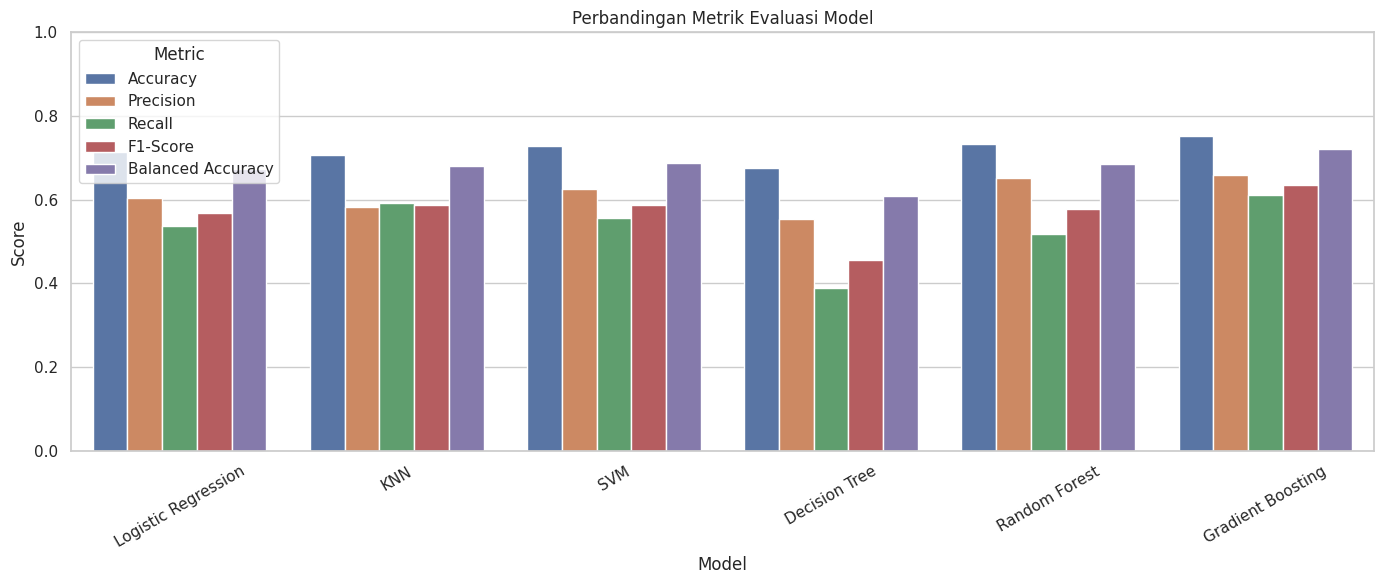

In [104]:
# Visualisasi perbandingan accuracy, precision, recall, dan F1-score

evaluation_results_melted = evaluation_results.melt(
    id_vars='Model',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Balanced Accuracy'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=evaluation_results_melted,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.title('Perbandingan Metrik Evaluasi Model')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

### 9.4 Confusion Matrix

Confusion matrix digunakan untuk melihat detail jumlah prediksi benar dan salah.

Pada kasus klasifikasi diabetes, confusion matrix terdiri dari:

- True Negative: pasien tidak diabetes dan diprediksi tidak diabetes.
- False Positive: pasien tidak diabetes tetapi diprediksi diabetes.
- False Negative: pasien diabetes tetapi diprediksi tidak diabetes.
- True Positive: pasien diabetes dan diprediksi diabetes.

False Negative perlu diperhatikan karena berarti pasien yang sebenarnya diabetes justru diprediksi tidak diabetes.

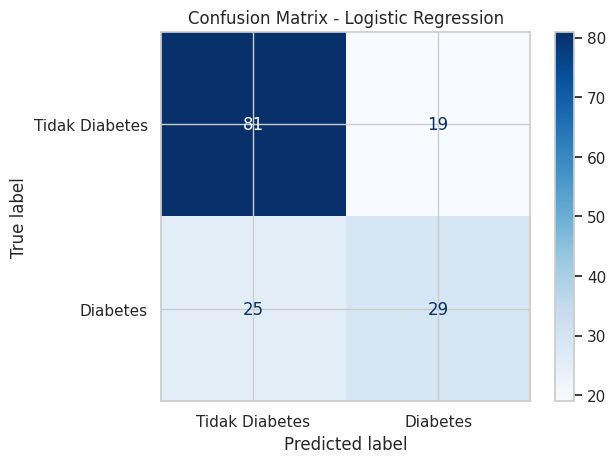

In [105]:
# Confusion matrix Logistic Regression

cm_logistic = confusion_matrix(y_test, y_test_pred_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=['Tidak Diabetes', 'Diabetes']
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

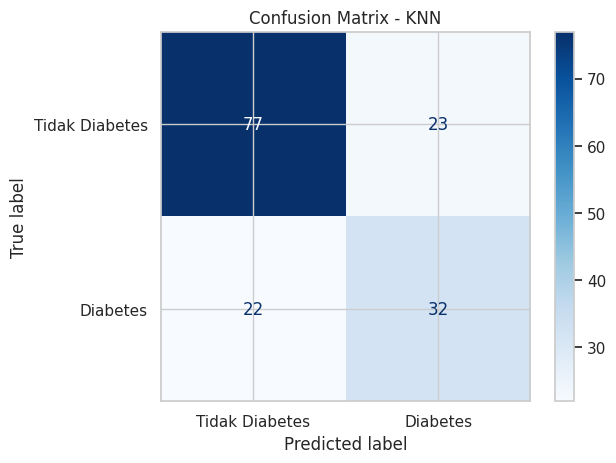

In [106]:
# Confusion matrix KNN

cm_knn = confusion_matrix(y_test, y_test_pred_knn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=['Tidak Diabetes', 'Diabetes']
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix - KNN')
plt.show()

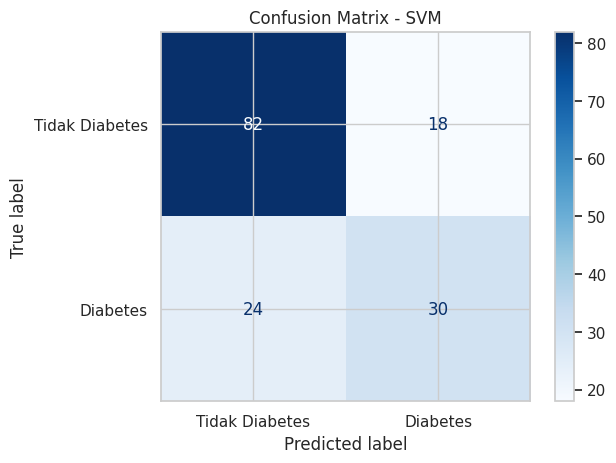

In [107]:
# Confusion matrix SVM

cm_svm = confusion_matrix(y_test, y_test_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=['Tidak Diabetes', 'Diabetes']
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix - SVM')
plt.show()

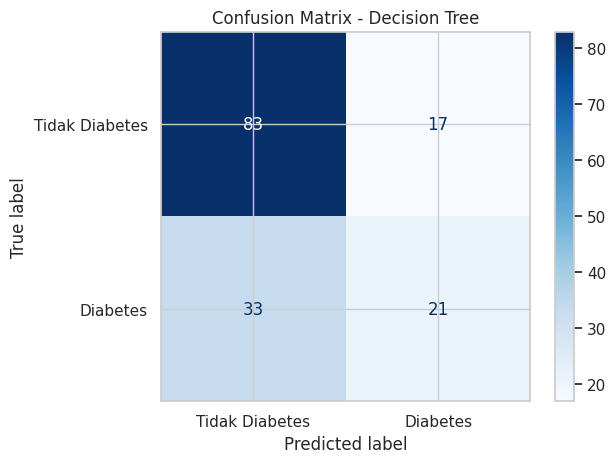

In [108]:
# Confusion matrix Decision Tree

cm_decision_tree = confusion_matrix(y_test, y_test_pred_decision_tree)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_decision_tree,
    display_labels=['Tidak Diabetes', 'Diabetes']
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

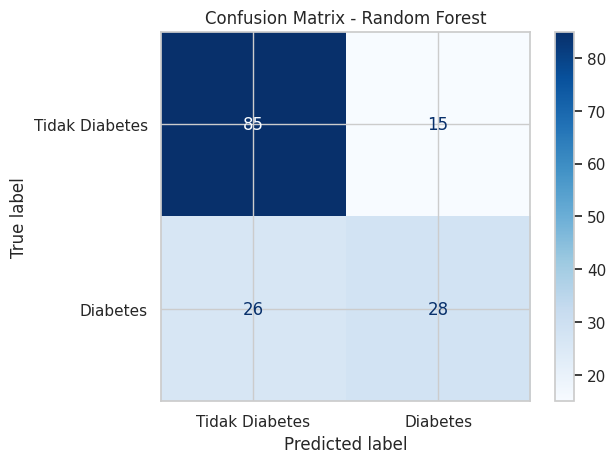

In [109]:
# Confusion matrix Random Forest

cm_random_forest = confusion_matrix(y_test, y_test_pred_random_forest)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_random_forest,
    display_labels=['Tidak Diabetes', 'Diabetes']
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.show()

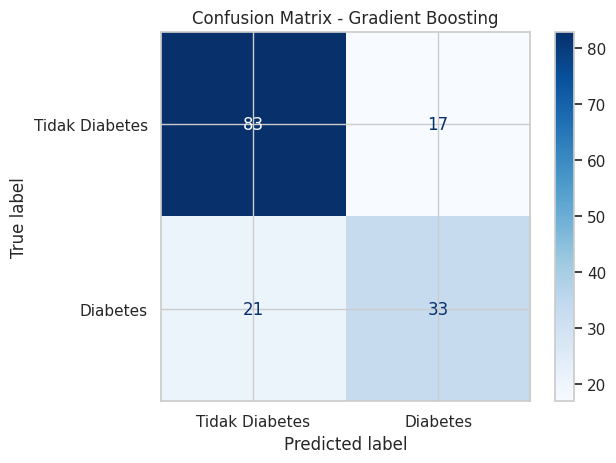

In [110]:
# Confusion matrix Gradient Boosting

cm_gradient_boosting = confusion_matrix(y_test, y_test_pred_gradient_boosting)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_gradient_boosting,
    display_labels=['Tidak Diabetes', 'Diabetes']
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Gradient Boosting')
plt.show()

### 9.5 Classification Report

Classification report menampilkan precision, recall, dan F1-score untuk masing-masing kelas.

Pada kasus ini, perhatian utama diberikan pada kelas `1` atau diabetes karena model perlu mampu mendeteksi pasien yang benar-benar terindikasi diabetes.

In [112]:
# Classification report Logistic Regression

print("Classification Report - Logistic Regression")
print(classification_report(y_test, y_test_pred_logistic, target_names=['Tidak Diabetes', 'Diabetes']))


Classification Report - Logistic Regression
                precision    recall  f1-score   support

Tidak Diabetes       0.76      0.81      0.79       100
      Diabetes       0.60      0.54      0.57        54

      accuracy                           0.71       154
     macro avg       0.68      0.67      0.68       154
  weighted avg       0.71      0.71      0.71       154



In [114]:
# Classification report KNN

print("Classification Report - KNN")
print(classification_report(y_test, y_test_pred_knn, target_names=['Tidak Diabetes', 'Diabetes']))

Classification Report - KNN
                precision    recall  f1-score   support

Tidak Diabetes       0.78      0.77      0.77       100
      Diabetes       0.58      0.59      0.59        54

      accuracy                           0.71       154
     macro avg       0.68      0.68      0.68       154
  weighted avg       0.71      0.71      0.71       154



In [115]:
# Classification report SVM

print("Classification Report - SVM")
print(classification_report(y_test, y_test_pred_svm, target_names=['Tidak Diabetes', 'Diabetes']))

Classification Report - SVM
                precision    recall  f1-score   support

Tidak Diabetes       0.77      0.82      0.80       100
      Diabetes       0.62      0.56      0.59        54

      accuracy                           0.73       154
     macro avg       0.70      0.69      0.69       154
  weighted avg       0.72      0.73      0.72       154



In [116]:
# Classification report Decision Tree

print("Classification Report - Decision Tree")
print(classification_report(y_test, y_test_pred_decision_tree, target_names=['Tidak Diabetes', 'Diabetes']))

Classification Report - Decision Tree
                precision    recall  f1-score   support

Tidak Diabetes       0.72      0.83      0.77       100
      Diabetes       0.55      0.39      0.46        54

      accuracy                           0.68       154
     macro avg       0.63      0.61      0.61       154
  weighted avg       0.66      0.68      0.66       154



In [117]:
# Classification report Random Forest

print("Classification Report - Random Forest")
print(classification_report(y_test, y_test_pred_random_forest, target_names=['Tidak Diabetes', 'Diabetes']))

Classification Report - Random Forest
                precision    recall  f1-score   support

Tidak Diabetes       0.77      0.85      0.81       100
      Diabetes       0.65      0.52      0.58        54

      accuracy                           0.73       154
     macro avg       0.71      0.68      0.69       154
  weighted avg       0.73      0.73      0.73       154



In [118]:
# Classification report Gradient Boosting

print("Classification Report - Gradient Boosting")
print(classification_report(y_test, y_test_pred_gradient_boosting, target_names=['Tidak Diabetes', 'Diabetes']))

Classification Report - Gradient Boosting
                precision    recall  f1-score   support

Tidak Diabetes       0.80      0.83      0.81       100
      Diabetes       0.66      0.61      0.63        54

      accuracy                           0.75       154
     macro avg       0.73      0.72      0.72       154
  weighted avg       0.75      0.75      0.75       154



### 9.6 Membandingkan Training Accuracy dan Testing Accuracy

Setelah evaluasi pada data testing, training accuracy dan testing accuracy dibandingkan.

Perbandingan ini membantu melihat kemungkinan overfitting atau underfitting.

- Jika training accuracy jauh lebih tinggi daripada testing accuracy, model kemungkinan overfitting.
- Jika training accuracy dan testing accuracy sama-sama rendah, model kemungkinan underfitting.
- Jika keduanya cukup seimbang, model cenderung memiliki generalisasi yang lebih baik.

In [119]:
# Membandingkan training accuracy dan testing accuracy

train_test_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'SVM',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Training Accuracy': [
        train_acc_logistic,
        train_acc_knn,
        train_acc_svm,
        train_acc_decision_tree,
        train_acc_random_forest,
        train_acc_gradient_boosting
    ],
    'Testing Accuracy': [
        accuracy_logistic,
        accuracy_knn,
        accuracy_svm,
        accuracy_decision_tree,
        accuracy_random_forest,
        accuracy_gradient_boosting
    ]
})

train_test_comparison['Accuracy Gap'] = (
    train_test_comparison['Training Accuracy'] - train_test_comparison['Testing Accuracy']
).round(4)

train_test_comparison

,Model,Training Accuracy,Testing Accuracy,Accuracy Gap
0,Logistic Regression,0.794788,0.714286,0.0805
1,KNN,0.837134,0.707792,0.1293
2,SVM,0.830619,0.727273,0.1033
3,Decision Tree,1.000000,0.675325,0.3247
4,Random Forest,1.000000,0.733766,0.2662
5,Gradient Boosting,0.923453,0.753247,0.1702


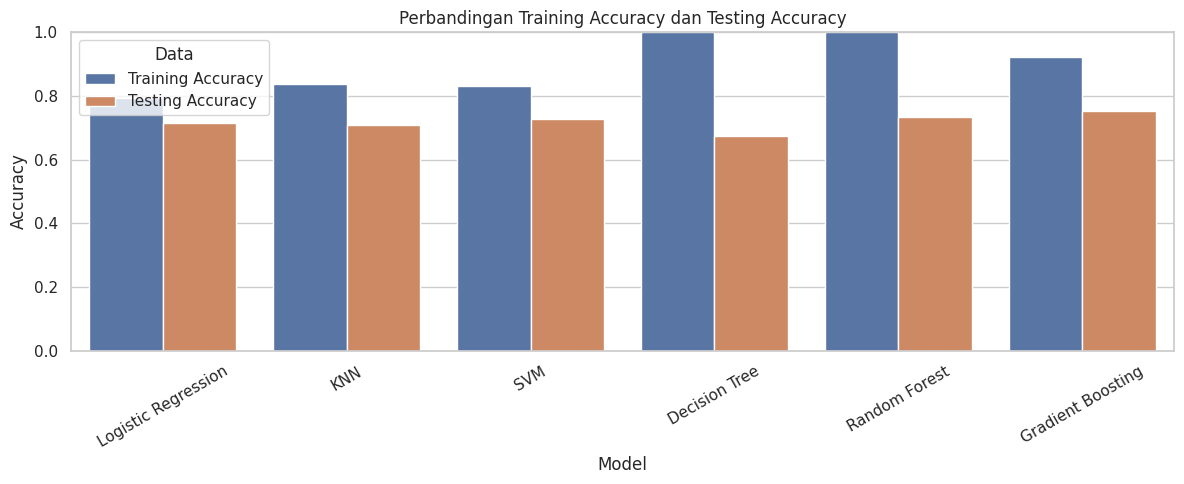

In [120]:
# Visualisasi perbandingan training accuracy dan testing accuracy

train_test_melted = train_test_comparison.melt(
    id_vars='Model',
    value_vars=['Training Accuracy', 'Testing Accuracy'],
    var_name='Data',
    value_name='Accuracy'
)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=train_test_melted,
    x='Model',
    y='Accuracy',
    hue='Data'
)

plt.title('Perbandingan Training Accuracy dan Testing Accuracy')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()